# EDA

In [2]:
%load_ext autoreload
%autoreload 2
import medmnist
import torch 
import random 
import numpy as np
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from utils import *
from medmnist import PathMNIST,INFO
from pathlib import Path
from tqdm import tqdm
from torchinfo import summary
from torchvision import models
from torchvision.models import ResNet18_Weights

In [3]:
ROOT_DIR = "./data"
# Create the directory if it doesn't exist
Path(ROOT_DIR).mkdir(parents=True, exist_ok=True)
SEED = 42
IMG_SIZE = (28, 28)
HIDDEN_SIZE = 256
CHANNELS = 3
NUM_CLASSES = 9
BATCH_SIZE = 64
EPOCHS_MLP = 10
EPOCHS_CNN = 40
EPOCHS_VIT = 10
EPOCHS_RESNET = 40
LEARNING_RATE = 1e-3
LEARNING_RATE_VIT = 1e-3

In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
dataset = PathMNIST(root=ROOT_DIR, split="train", download=True)

In [6]:
# Load PathMNIST info
data_flag = 'pathmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

In [7]:
info

{'python_class': 'PathMNIST',
 'description': 'The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.',
 'url': 'https://zenodo.org/records/10519652/files/pathmnist.npz?download=1',
 'MD5': 'a8b06965200029087d5bd730944a56c1',
 'url_64': 'https://zenodo.org/records/10519652/files/pathmnist_64.npz?download=1',
 'MD5_64': '55aa9c1e0525abe5a6b9d8343a507616',
 'url_128': 'https://zenodo.org/records/10519652/files/pathmnist_128.npz?download=1',
 'MD5

In [8]:
print(f"Number of samples: {len(dataset)}")

Number of samples: 89996


In [9]:
for key, value in dataset.info['label'].items():
    print(f"Class {key} : {value}")

Class 0 : adipose
Class 1 : background
Class 2 : debris
Class 3 : lymphocytes
Class 4 : mucus
Class 5 : smooth muscle
Class 6 : normal colon mucosa
Class 7 : cancer-associated stroma
Class 8 : colorectal adenocarcinoma epithelium


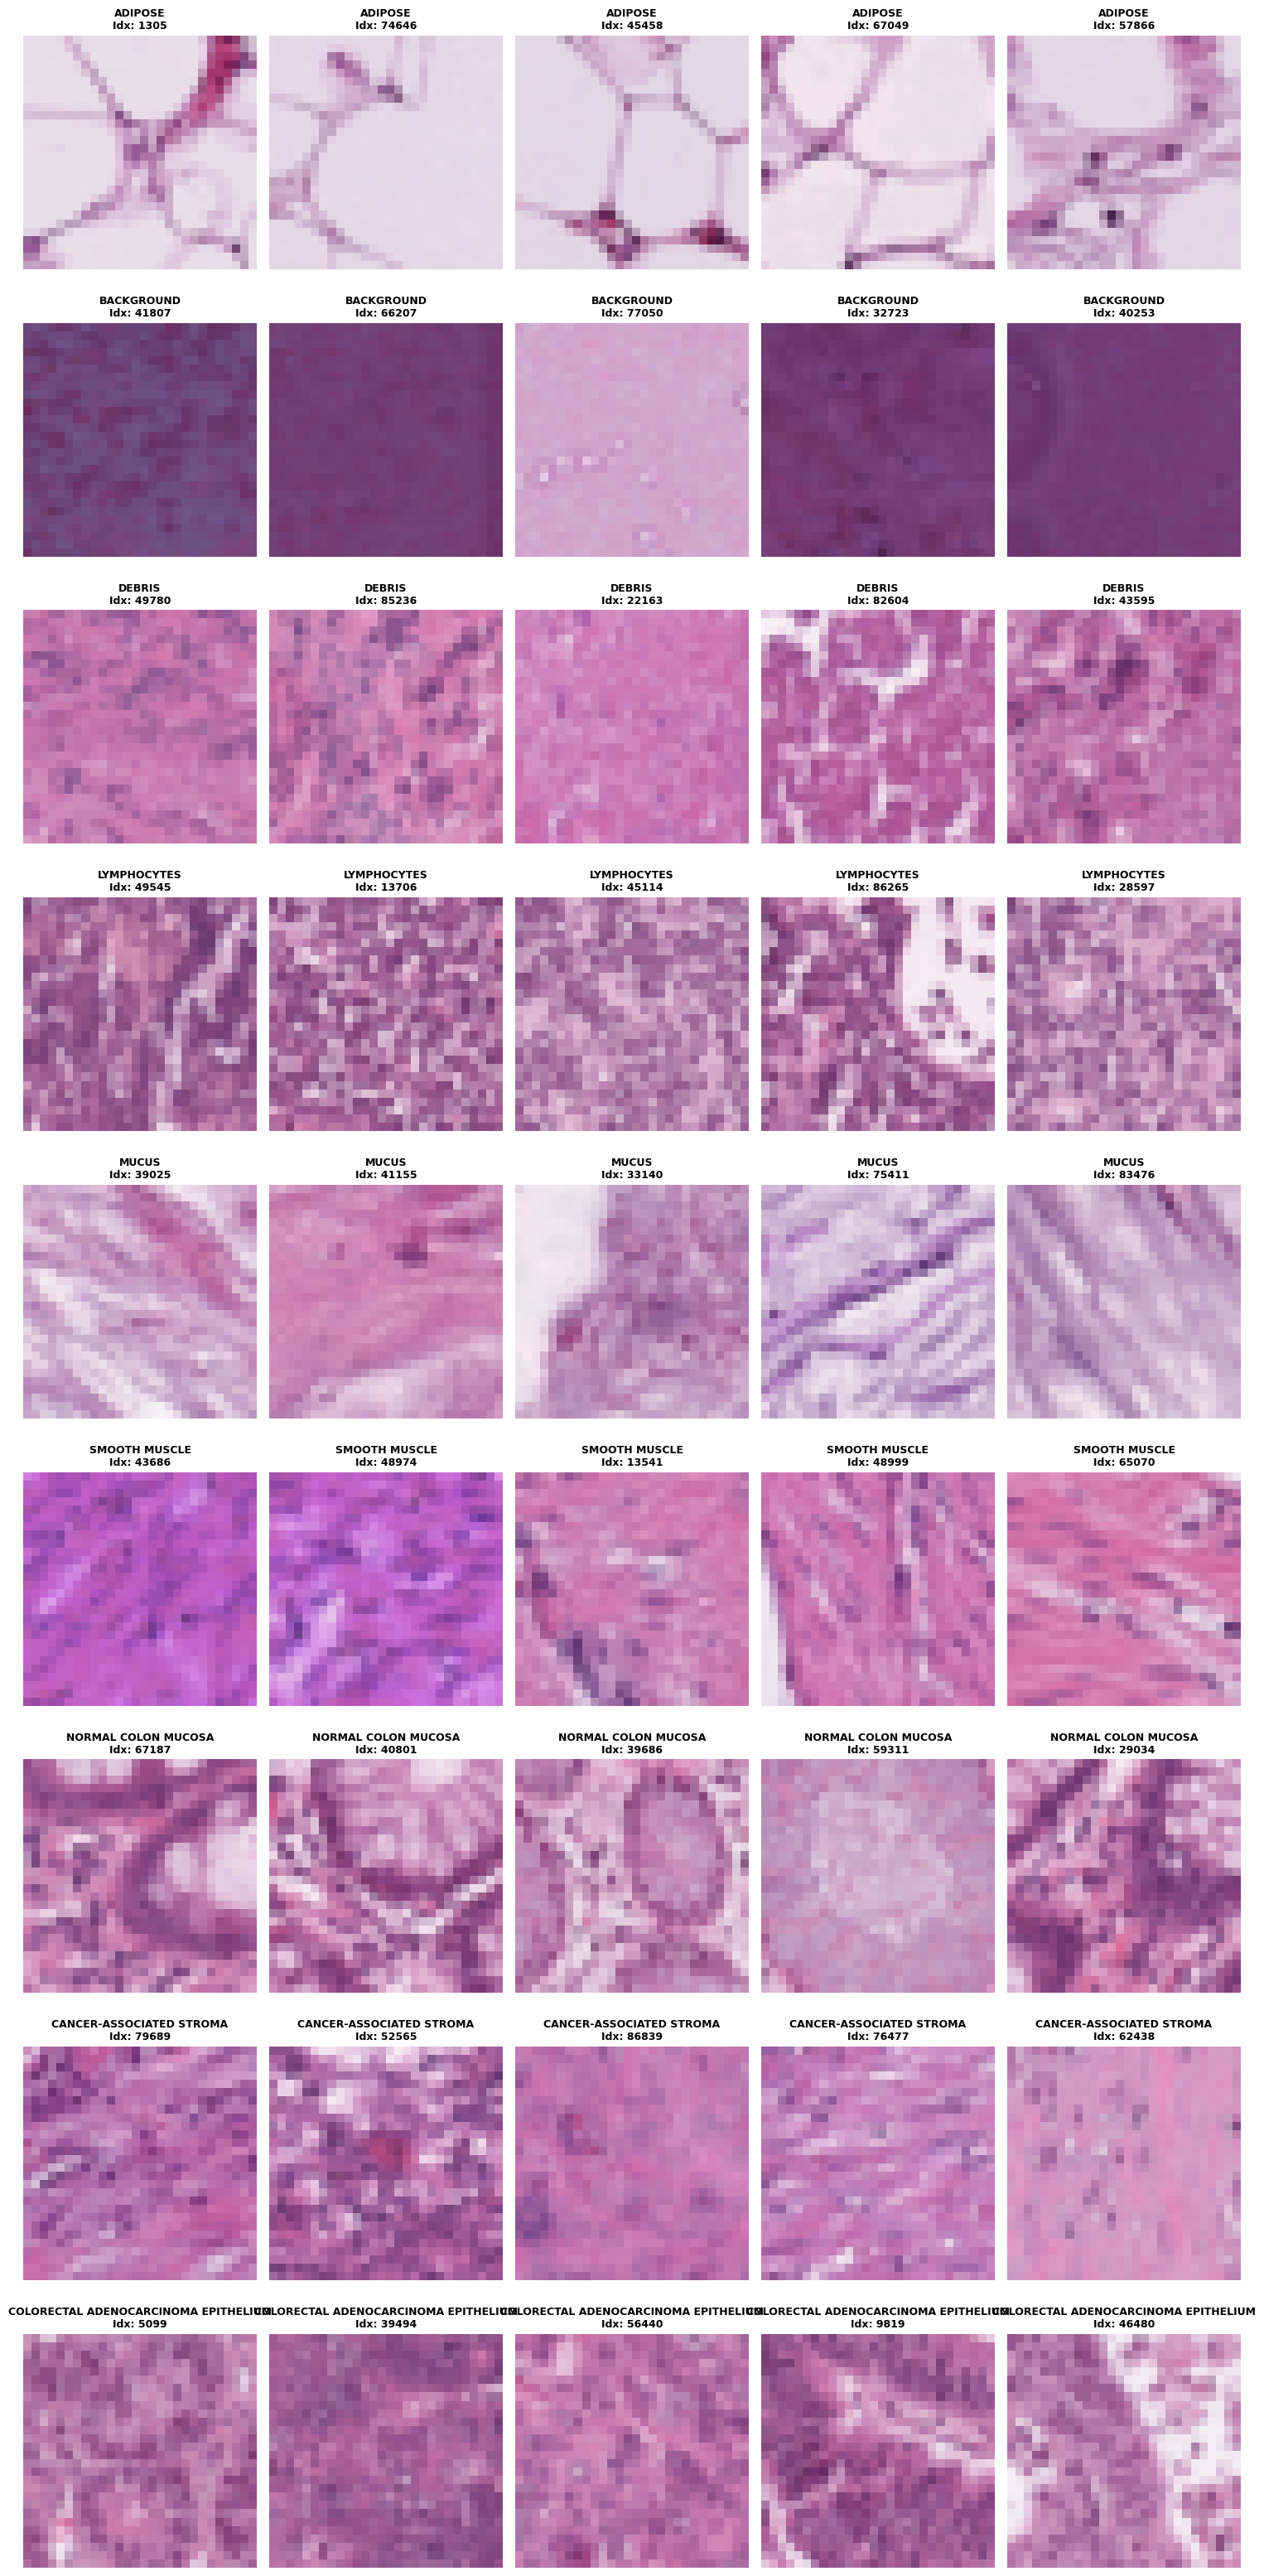

In [89]:
display_medmnist_samples(dataset,"*",5)

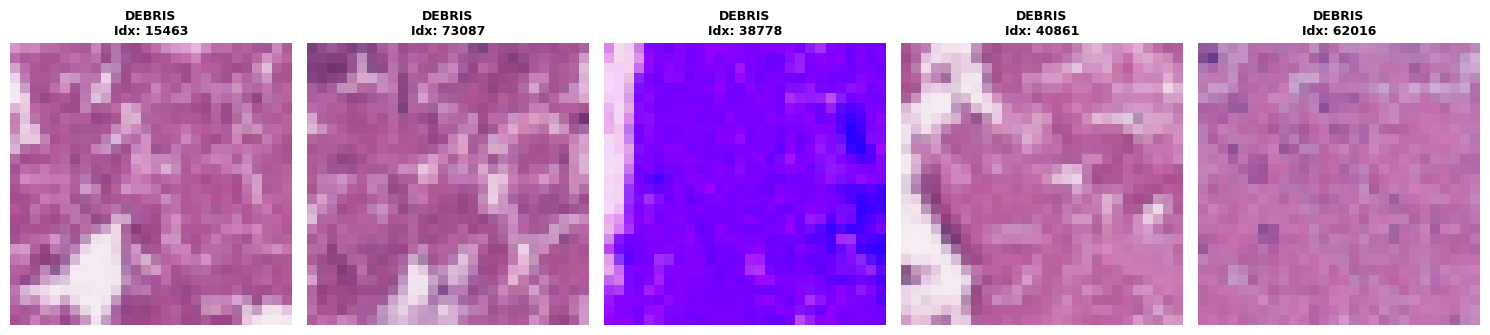

In [90]:
display_medmnist_samples(dataset,"debris",5)

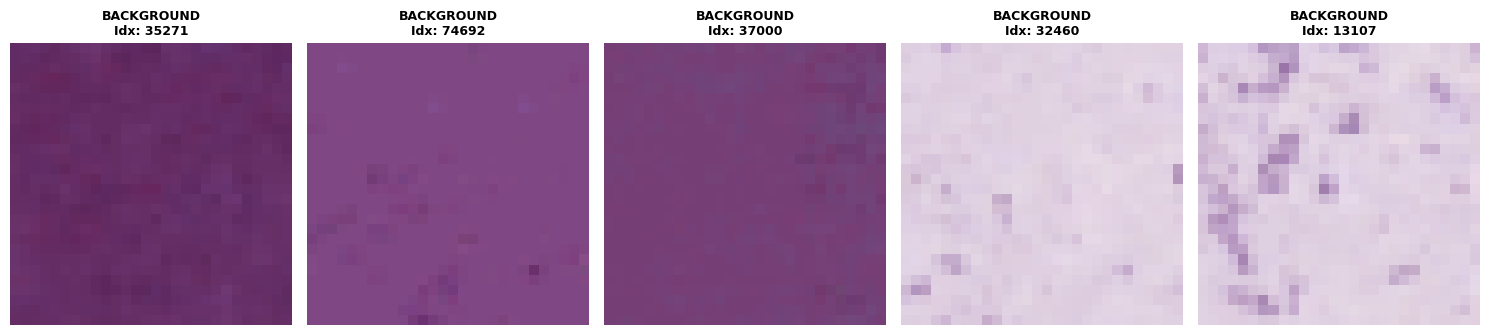

In [91]:
display_medmnist_samples(dataset,"background",5)

Q1.1 - Les classes se distinguent principalement par leur niveau d’organisation structurelle (organisé vs désorganisé), leur densité cellulaire, et leur rôle biologique, ainsi les 9 classes peuvent etre réduites à 4 blocs logiques (tissu normal, cellule isolée, sécrétion ou pathologie).

En observant plusieurs images de la classe Debris et en les comparant avec celles de la classe Background, on remarque des différences visuelles nettes.

Les images de la classe Debris présentent généralement des fragments irréguliers et des structures plus hétérogènes. On y observe souvent une texture plus complexe, avec des amas de formes ou des contours marqués qui se détachent du reste de l’image. Les couleurs peuvent aussi varier davantage, avec des zones plus sombres ou plus denses.

À l’inverse, les images de la classe Background apparaissent plus uniformes et plus lisses. La texture est généralement plus homogène, avec peu de structures distinctes ou de contours marqués. Les couleurs sont aussi plus régulières, souvent dominées par des tons rosés ou violacés relativement constants.

Ainsi, les images Debris se caractérisent par des textures irrégulières et des motifs plus complexes, tandis que les images Background sont plus homogènes et moins structurées visuellement.

In [92]:
print_dataset_structure(dataset)

--- Dataset Structure: PATHMNIST ---
Total samples: 89996
Image shape: (89996, 28, 28, 3)
Labels shape: (89996, 1)
Mode: RGB


In [93]:
plot_class_distribution(dataset)

--- Pixel Stats: Mean=168.25, Std=43.36, Min=0, Max=255 ---


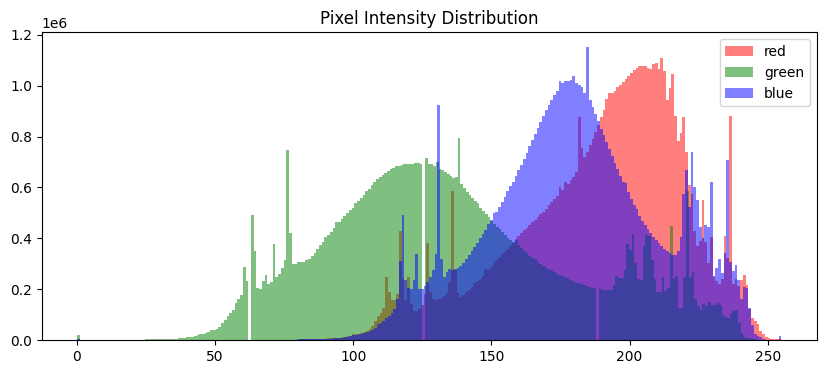

In [94]:
show_pixel_stats(dataset)

--- Stats for Image Index: 15795 (Seed: 42) ---
Shape: (28, 28, 3)
Red   Channel -> Mean: 128.48 | Std: 10.92
Green Channel -> Mean: 71.84 | Std: 7.18
Blue  Channel -> Mean: 125.65 | Std: 9.77
Global Stats -> Min: 11 | Max: 139


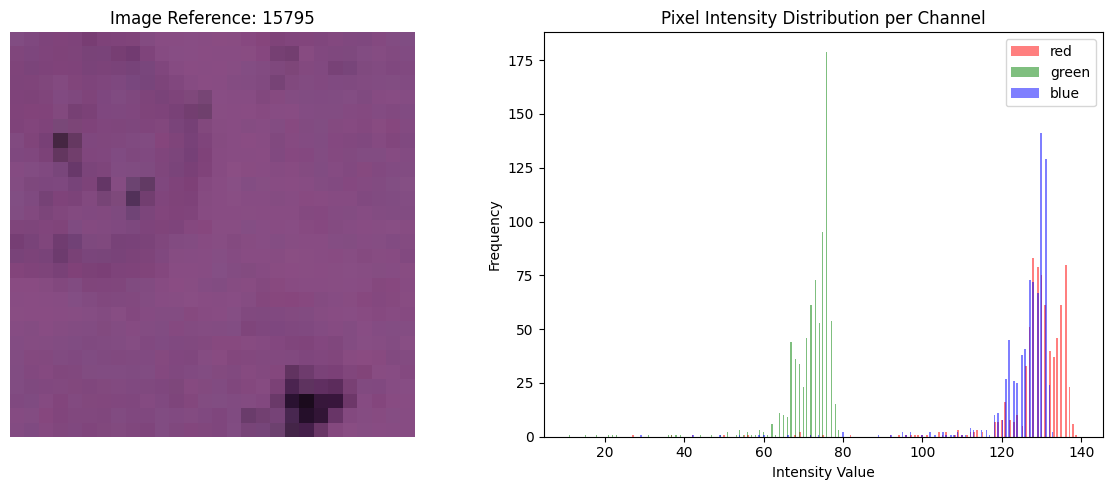

In [95]:
show_random_pixel_stats(dataset)

# Transformations

Pour cette analyse, nous avons sélectionné une image aléatoire du jeu d'entraînement (index : 15795, seed : 42). L'image est un tenseur RGB de taille $28 \times 28 \times 3$.

In [10]:
transform_train = transforms.Compose([
    # 1. Random data augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    
    # 2. Tensor conversion
    transforms.ToTensor(),
    
    # 3. ImageNet normalization
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [11]:
# 2. Load the 3 splits (it only downloads once!)
train_dataset = PathMNIST(root=ROOT_DIR, split="train", transform=transform_train, download=False)
val_dataset   = PathMNIST(root=ROOT_DIR, split="val",   transform=transform_test, download=False)
test_dataset  = PathMNIST(root=ROOT_DIR, split="test",  transform=transform_test, download=False)

# 3. Create your loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [44]:
train_dataset_notransform = PathMNIST(root=ROOT_DIR, split="train", transform=transform_test ,download=False)
val_dataset_notransform   = PathMNIST(root=ROOT_DIR, split="val", transform=transform_test ,download=False)
test_dataset_notransform  = PathMNIST(root=ROOT_DIR, split="test", transform=transform_test ,download=False)

# 3. Create your loaders
train_loader_notransform = DataLoader(train_dataset_notransform, batch_size=BATCH_SIZE, shuffle=True)
val_loader_notransform   = DataLoader(val_dataset_notransform,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_notransform  = DataLoader(test_dataset_notransform,  batch_size=BATCH_SIZE, shuffle=False)

**Les statistiques d'intensité des pixels pour cet échantillon précis (sur une échelle de 0 à 255) sont les suivantes :** \
Canal rouge $\rightarrow$ Moyenne : $128.48$ ($\approx 0.504$) | Écart-type : $10.92$ ($\approx 0.043$) \
Canal vert $\rightarrow$ Moyenne : $71.84$ ($\approx 0.282$) | Écart-type : $7.18$ ($\approx 0.028$) \
Canal bleu $\rightarrow$ Moyenne : $125.65$ ($\approx 0.493$) | Écart-type : $9.77$ ($\approx 0.038$) \
Moyenne globale ($\mu$) : $108.66$ (normalisée : $0.426$) \
Écart-type global ($\sigma$) : $27.71$ (normalisé : $0.108$) \
Plage dynamique : min : $11$ / max : $139$ (normalisé : $0.043$ / $0.545$)

**Les statistiques ImageNet, utilisées comme référence standard pour les jeux d'images naturelles, sont généralement :** \
Moyenne ImageNet : $\approx [0.485, 0.456, 0.406]$ (moyenne $\approx 0.449$) \
Écart-type ImageNet : $\approx [0.229, 0.224, 0.225]$ (moyenne $\approx 0.226$)

L'analyse statistique révèle un biais de couleur marqué et un faible contraste dans cet échantillon. Les fortes valeurs moyennes dans les canaux rouge ($0.504$) et bleu ($0.493$), comparées au canal vert beaucoup plus faible ($0.282$), confirment quantitativement la teinte rose/violette de la coloration H&E observée visuellement. De plus, l'écart-type par canal reste très faible (de $0.028$ à $0.043$) par rapport à la moyenne ImageNet de $0.226$. Cela indique que les pixels sont très concentrés autour d'une teinte spécifique, avec peu de variation de luminosité, ce qui est caractéristique des régions de fond homogènes en histopathologie.

# Training loop

In [72]:
def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device).squeeze().long()
            
            # Forward + Backward
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Stats
            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)
            loop.set_postfix(loss=loss.item())

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze().long()
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        # Store metrics
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(100. * train_correct / train_total)
        history['val_loss'].append(val_loss / val_total)
        history['val_acc'].append(100. * val_correct / val_total)
        
        print(f"Summary Epoch {epoch+1}: Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.2f}%")
        
    return history

# MLP

In [73]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout_prob=0.2): # Dropout réduit
        super(MLP, self).__init__()
        
        # Layer 1
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size) # BatchNorm
        
        # Layer 2 (Option: hidden_size // 2 for funnel effect)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        
        # Output layer
        self.fc3 = nn.Linear(hidden_size, num_classes)
        
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        
        # Bloc 1
        x = self.fc1(x)
        x = self.bn1(x) # Normalise avant l'activation
        x = F.relu(x)
        x = self.dropout(x)
        
        # Bloc 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Sortie (Pas de ReLU ni de Dropout ici !)
        return self.fc3(x)

In [74]:
baseline = MLP(input_size=IMG_SIZE[0] * IMG_SIZE[1] * CHANNELS, hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES)

In [75]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline = baseline.to(device)
print(baseline)

MLP(
  (fc1): Linear(in_features=2352, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=9, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


In [76]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=LEARNING_RATE)

In [77]:
history = train_and_evaluate(baseline, train_loader, val_loader, criterion, optimizer, EPOCHS_MLP, device)

Epoch 1/10:   0%|          | 0/1407 [00:00<?, ?it/s]

Epoch 1/10: 100%|██████████| 1407/1407 [00:12<00:00, 113.16it/s, loss=1.14] 


Summary Epoch 1: Val Loss: 0.9379 | Val Acc: 65.17%


Epoch 2/10: 100%|██████████| 1407/1407 [00:12<00:00, 111.55it/s, loss=1.1]  


Summary Epoch 2: Val Loss: 0.8755 | Val Acc: 66.93%


...

Summary Epoch 8: Val Loss: 0.7671 | Val Acc: 70.90%


Epoch 9/10: 100%|██████████| 1407/1407 [00:12<00:00, 112.30it/s, loss=1.28] 


Summary Epoch 9: Val Loss: 0.7652 | Val Acc: 70.36%


Epoch 10/10: 100%|██████████| 1407/1407 [00:12<00:00, 113.03it/s, loss=0.991]


Summary Epoch 10: Val Loss: 0.8004 | Val Acc: 70.08%


Test accuracy:
0.6005571030640668
Confusion matrix:
[[982 238   6   0  56  43   0   0  13]
 [  0 847   0   0   0   0   0   0   0]
 [  0   9 164   0   0 124   0  40   2]
 [ 11   6  25 201  84  14 107   0 186]
 [ 30 334   3   2 630   3  19   3  11]
 [  0  57 218   0   1 241   0  68   7]
 [  1   1  17   1  66  23 205   0 427]
 [  0   6 140   0  11  43   0 163  58]
 [  2   3 177   2  19   9 139   3 879]]


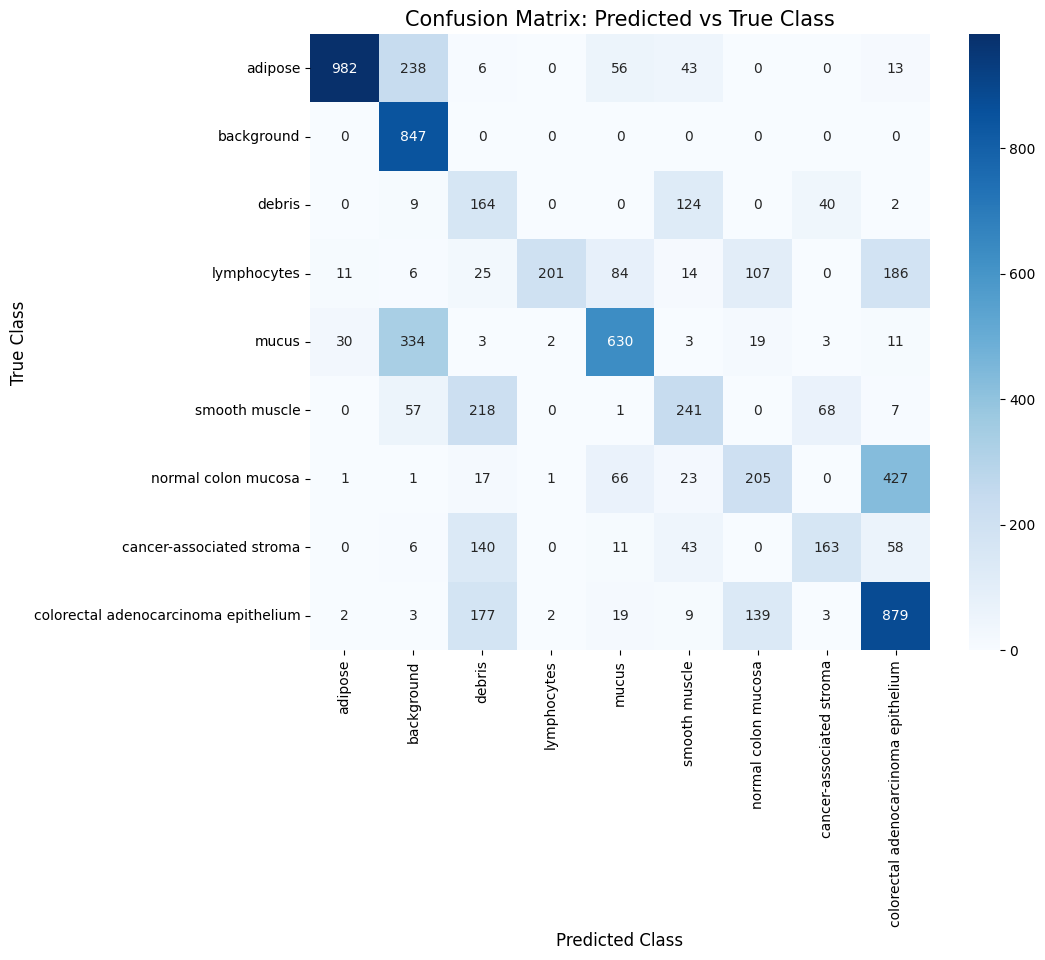

In [78]:
test_acc = eval_test(baseline, test_loader, device)

print("Test accuracy:")
print("="*20)
print(test_acc[0])
print("Confusion matrix:")
print("="*20)
print(test_acc[1])
# noms des classes PathMNIST
class_names = INFO["pathmnist"]["label"]

# matrice de confusion
plot_confusion_matrix(baseline, test_loader, device, class_names);

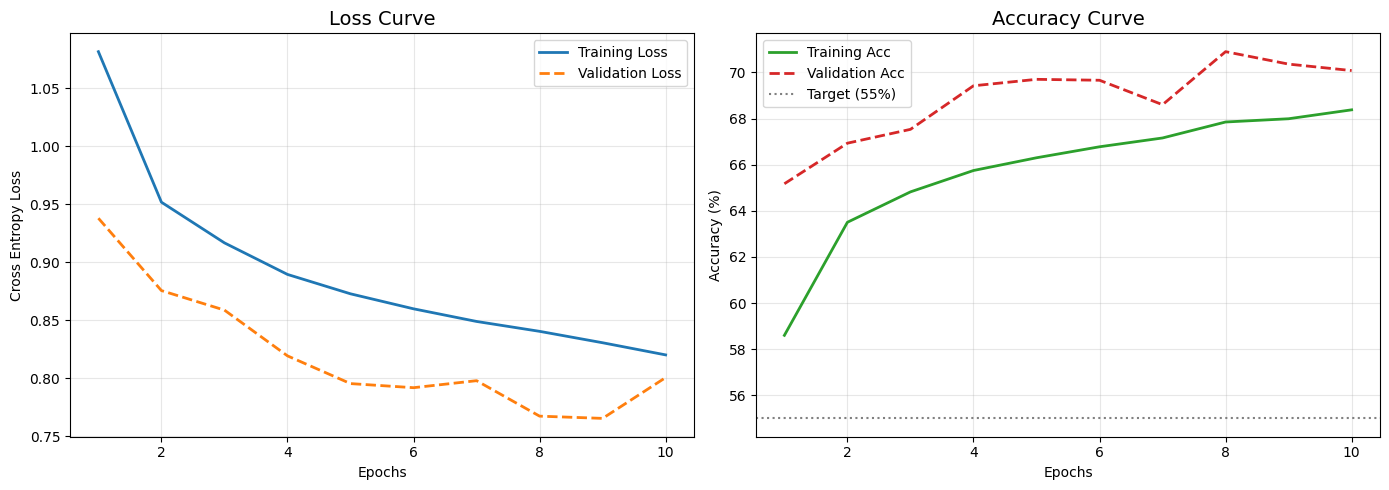

In [79]:
plot_training_history(history)

In [106]:
evaluate_test_accuracy(baseline, test_loader, device)

64.70752089136491

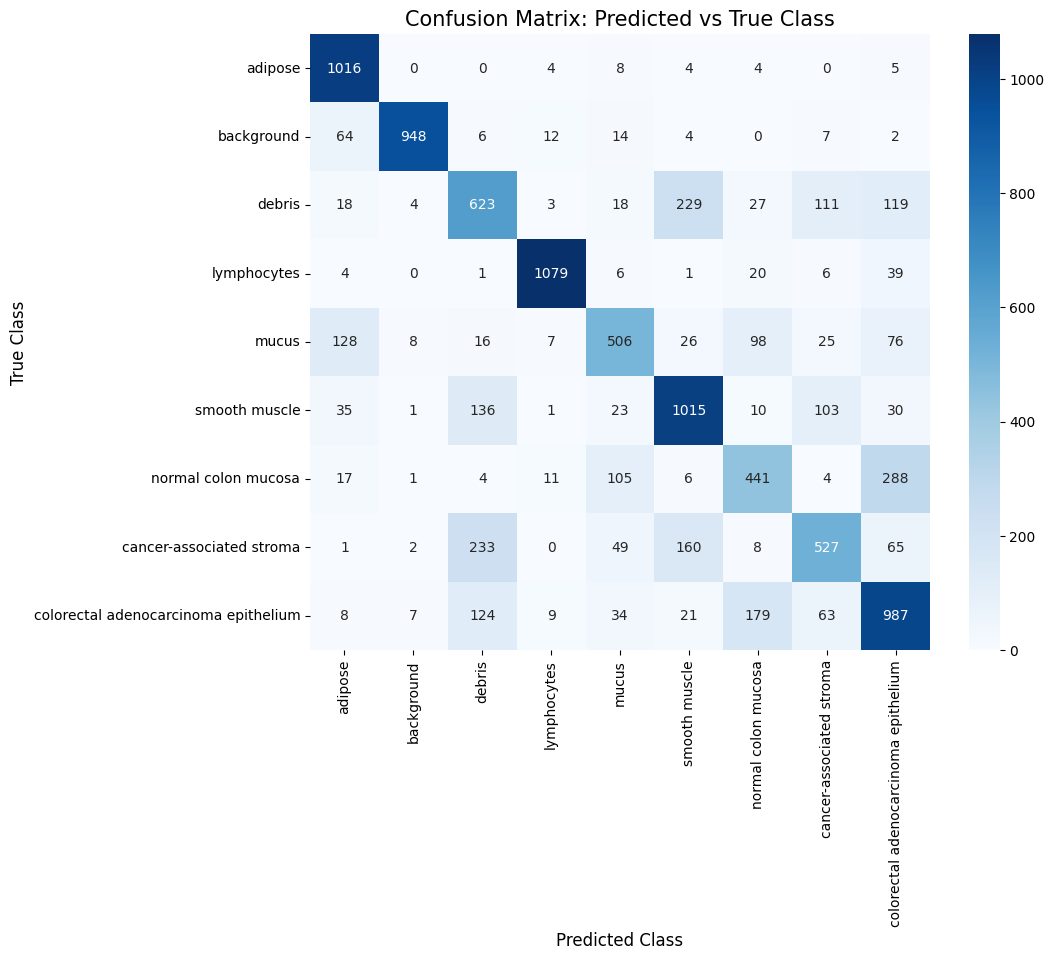

In [107]:
class_names = [train_dataset.info['label'][str(i)] for i in range(9)]
cm = plot_confusion_matrix(baseline, val_loader, device, class_names);

In [108]:
print("Train acc — epoch 1:", history["train_acc"][0])
print("Train acc — epoch 10:", history["train_acc"][9])
print("Train acc — final epoch:", history["train_acc"][-1])

print("Val acc — epoch 1:", history["val_acc"][0])
print("Val acc — epoch 10:", history["val_acc"][9])
print("Val acc — final epoch:", history["val_acc"][-1])

Train acc — epoch 1: 58.55038001688964
Train acc — epoch 10: 68.25747811013822
Train acc — final epoch: 68.25747811013822
Val acc — epoch 1: 65.47381047580967
Val acc — epoch 10: 71.39144342263094
Val acc — final epoch: 71.39144342263094


In [109]:
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

In [110]:
true_idx, pred_idx = np.unravel_index(np.argmax(cm_errors), cm_errors.shape)
max_error_count = cm_errors[true_idx, pred_idx]

print(f"Highest Misclassification: {max_error_count} instances")
print(f"True Class: {class_names[true_idx]} (Index {true_idx})")
print(f"Predicted as: {class_names[pred_idx]} (Index {pred_idx})")

Highest Misclassification: 288 instances
True Class: normal colon mucosa (Index 6)
Predicted as: colorectal adenocarcinoma epithelium (Index 8)


La plus forte confusion observée pour le MLP apparaît entre la classe vraie **normal colon mucosa** et la classe prédite **colorectal adenocarcinoma epithelium**, avec **288** cas sur la matrice de confusion de validation.

Cette confusion est plausible pour plusieurs raisons:

- Similarité morphologique: ce sont deux tissus épithéliaux qui peuvent partager des textures et contrastes proches.
- Recouvrement visuel: certaines structures glandulaires normales peuvent présenter des motifs partiellement similaires à des structures tumorales.
- Limitation du MLP: sans convolutions, le MLP exploite surtout des corrélations d'intensité globales et capture moins bien l'organisation spatiale fine des tissus.

# CNN

In [53]:
class CNNFromScratch(nn.Module):
    def __init__(self, in_channels=3, num_classes=9, p_drop=0.3):
        super().__init__()

        # Block 1: 28x28 -> 14x14
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(p_drop),
            nn.MaxPool2d(2)
        )

        # Block 2: 14x14 -> 7x7
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(p_drop),
            nn.MaxPool2d(2)
        )

        # Block 3: 7x7 -> 7x7 (puis GAP)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(p_drop)
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

cnn = CNNFromScratch(in_channels=3, num_classes=9, p_drop=0.3).to(device)
print(cnn)

CNNFromScratch(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
  )
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc): Linear(in_fea

In [54]:
total_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

# Params of the first conv layer
conv1 = cnn.block1[0]
in_ch = conv1.in_channels      # 3
out_ch = conv1.out_channels    # 32
kH, kW = conv1.kernel_size     # (3,3)
bias = 1 if conv1.bias is not None else 0

conv1_params = out_ch * (in_ch * kH * kW + bias)
print("Conv1 params (computed):", conv1_params)

# PyTorch check
conv1_params_torch = sum(p.numel() for p in conv1.parameters() if p.requires_grad)
print("Conv1 params (torch):", conv1_params_torch)

Total trainable parameters: 94857
Conv1 params (computed): 896
Conv1 params (torch): 896


**AVEC data augmentation**

In [56]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=LEARNING_RATE)

history_cnn = train_and_evaluate(
    cnn,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=EPOCHS_CNN,
    device=device
)

Epoch 1/40: 100%|██████████| 1407/1407 [00:13<00:00, 105.73it/s, loss=0.512]


Summary Epoch 1: Val Loss: 0.4558 | Val Acc: 85.32%


Epoch 2/40: 100%|██████████| 1407/1407 [00:13<00:00, 105.96it/s, loss=0.758]


Summary Epoch 2: Val Loss: 0.5035 | Val Acc: 82.45%


Epoch 3/40: 100%|██████████| 1407/1407 [00:13<00:00, 105.42it/s, loss=1.04] 


...

Summary Epoch 6: Val Loss: 0.3955 | Val Acc: 87.07%


Epoch 7/40: 100%|██████████| 1407/1407 [00:13<00:00, 105.20it/s, loss=0.567]


Summary Epoch 7: Val Loss: 0.3630 | Val Acc: 87.30%


Epoch 8/40:  85%|████████▍ | 1190/1407 [00:11<00:02, 104.08it/s, loss=0.439]


KeyboardInterrupt: 

In [ ]:
# Q3.1 — First epoch where the gap (train_acc - val_acc) exceeds 15 points
gaps = [tr - va for tr, va in zip(history_cnn["train_acc"], history_cnn["val_acc"])]

first_epoch = None
for i, g in enumerate(gaps):
    if g > 15:
        first_epoch = i + 1  # epochs start at 1
        break

print("First epoch with gap > 15:", first_epoch)

if first_epoch is not None:
    i = first_epoch - 1
    print("Train acc :", history_cnn["train_acc"][i])
    print("Val acc :", history_cnn["val_acc"][i])
    print("Gap :", gaps[i])
else:
    print("No epoch where train_acc - val_acc > 15 over these", EPOCHS_CNN, "epochs.")

First epoch with gap > 15: None
No epoch where train_acc - val_acc > 15 over these 40 epochs.


Nous avons entraîné le CNN sur 40 epochs **avec data augmentation légère** (flip horizontal et rotation) et analysé l'écart entre `train_acc` et `val_acc`.

Le premier epoch où l'écart `train_acc - val_acc` dépasse 15 points est `None` (aucun sur 40 epochs). Cela indique qu'on n'observe pas de surapprentissage marqué selon ce critère, et que la généralisation validation reste globalement correcte dans cette configuration.

**TEST ACC**

CNN TEST accuracy: 0.8610027855153203


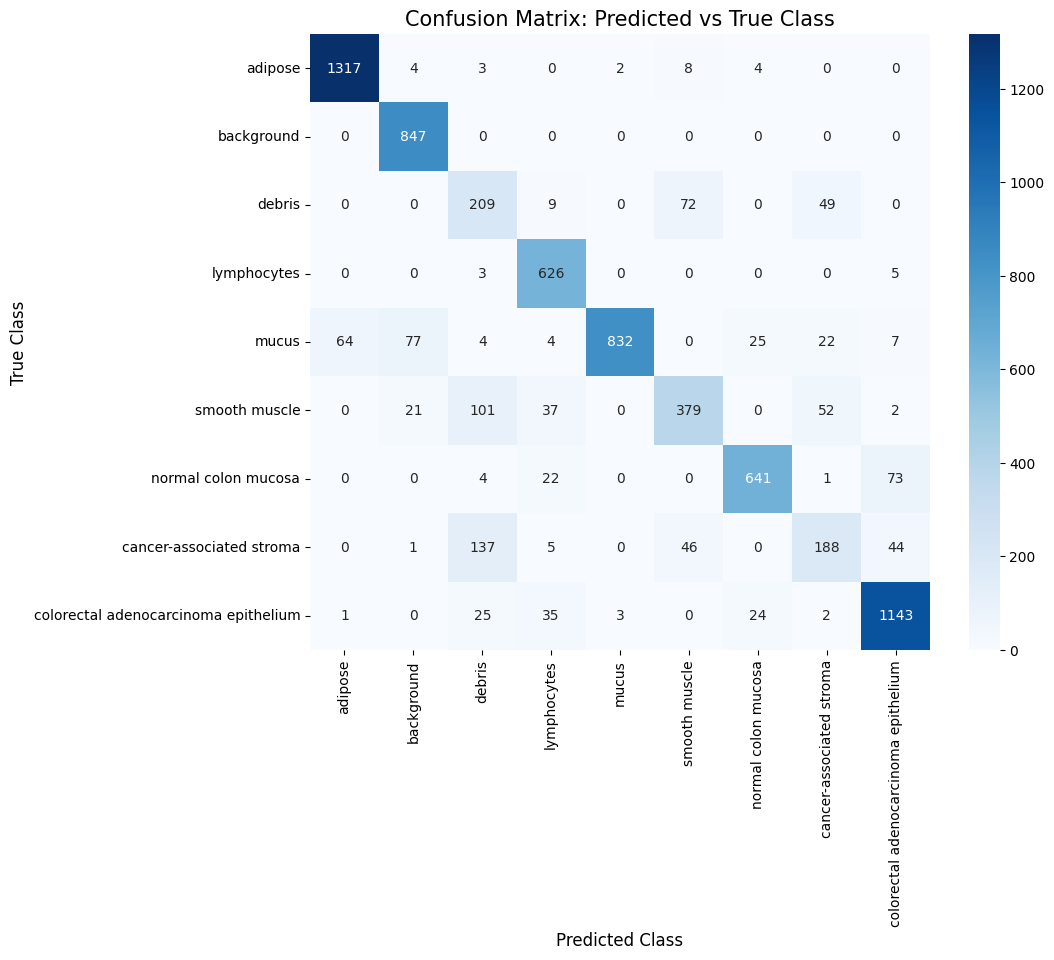

array([[1317,    4,    3,    0,    2,    8,    4,    0,    0],
       [   0,  847,    0,    0,    0,    0,    0,    0,    0],
       [   0,    0,  209,    9,    0,   72,    0,   49,    0],
       [   0,    0,    3,  626,    0,    0,    0,    0,    5],
       [  64,   77,    4,    4,  832,    0,   25,   22,    7],
       [   0,   21,  101,   37,    0,  379,    0,   52,    2],
       [   0,    0,    4,   22,    0,    0,  641,    1,   73],
       [   0,    1,  137,    5,    0,   46,    0,  188,   44],
       [   1,    0,   25,   35,    3,    0,   24,    2, 1143]])

In [ ]:
test_acc_cnn, test_cm_cnn = eval_test(cnn, test_loader, device)
print("CNN TEST accuracy:", test_acc_cnn)

# noms des classes (PathMNIST)
class_names = INFO["pathmnist"]["label"]
plot_confusion_matrix(cnn, test_loader, device, class_names)

**VAL ACC**

CNN TEST accuracy: 0.8764494202319072


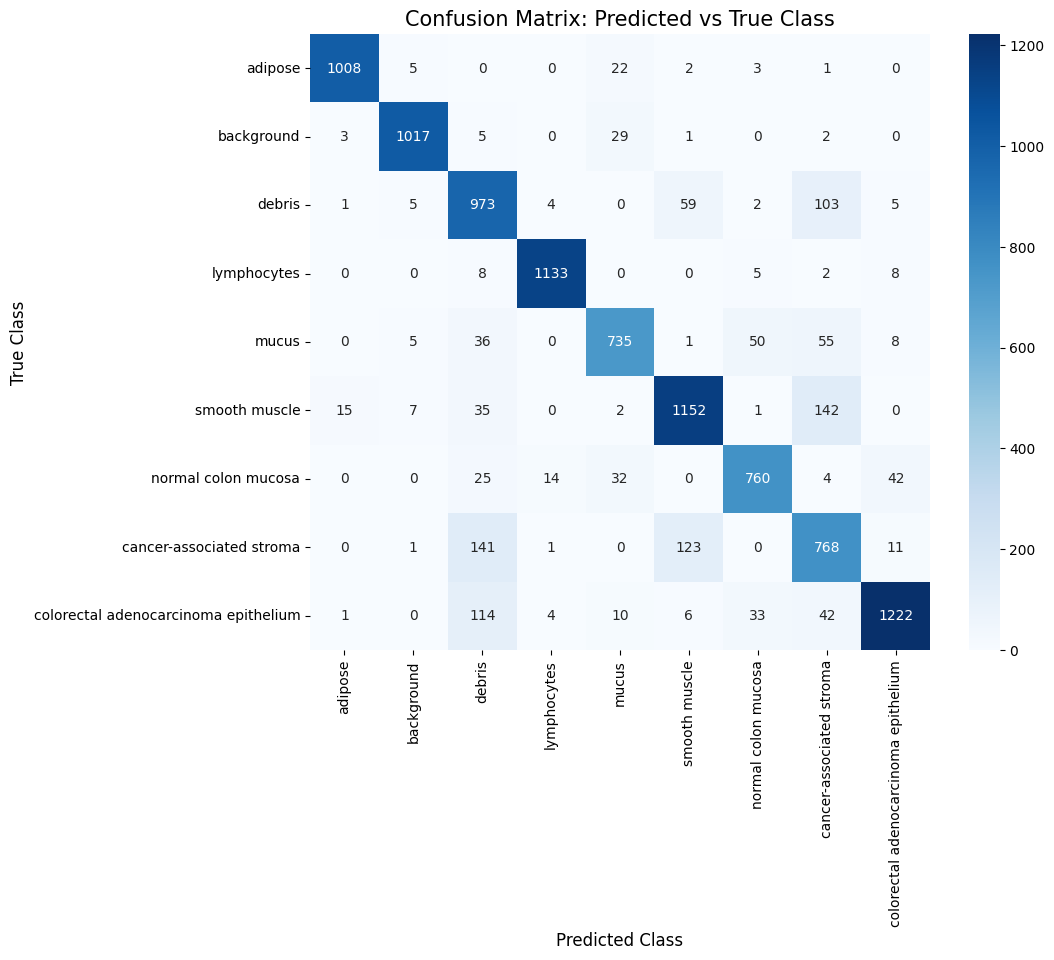

array([[1008,    5,    0,    0,   22,    2,    3,    1,    0],
       [   3, 1017,    5,    0,   29,    1,    0,    2,    0],
       [   1,    5,  973,    4,    0,   59,    2,  103,    5],
       [   0,    0,    8, 1133,    0,    0,    5,    2,    8],
       [   0,    5,   36,    0,  735,    1,   50,   55,    8],
       [  15,    7,   35,    0,    2, 1152,    1,  142,    0],
       [   0,    0,   25,   14,   32,    0,  760,    4,   42],
       [   0,    1,  141,    1,    0,  123,    0,  768,   11],
       [   1,    0,  114,    4,   10,    6,   33,   42, 1222]])

In [57]:
test_acc_cnn, test_cm_cnn = eval_test(cnn, val_loader, device)
print("CNN TEST accuracy:", test_acc_cnn)

# noms des classes (PathMNIST)
class_names = INFO["pathmnist"]["label"]
plot_confusion_matrix(cnn, val_loader, device, class_names)

Le CNN démontre une excellente robustesse sur les classes structurellement simples (Adipose, Background, Epithelium). Néanmoins, la performance chute sur les classes stromales et fibreuses. Le Cancer-associated stroma est la classe la plus problématique, étant plus souvent confondu avec les Debris qu'identifié correctement. Cela indique que si le CNN surpasse le MLP grâce à l'analyse de texture, la distinction entre les types de tissus conjonctifs et les artefacts (debris) reste un défi majeur pour le modèle.

Les images histologiques n’ont pas d’orientation canonique : une coupe de tissu reste valide même si elle est tournée ou retournée. Une augmentation pertinente exploitant cette propriété est la rotation aléatoire (par exemple 90°, 180° ou 270°) ou les flip horizontaux et verticaux, car ces transformations ne modifient pas la structure biologique du tissu et permettent d’augmenter la diversité des données d’entraînement.

En revanche, certaines augmentations couramment utilisées pour les images naturelles peuvent être inadaptées pour l’histologie. Par exemple, un recadrage aléatoire agressif (random crop) peut supprimer des structures cellulaires importantes ou des motifs tissulaires essentiels pour la classification. Cela pourrait altérer l’information diagnostique contenue dans l’image et donc nuire à l’apprentissage du modèle.

Le CNN comporte 94 857 paramètres entraînables au total. Pour la première couche convolutionnelle, le nombre de paramètres peut être calculé avec la formule suivante :
out_channels × (in_channels × kH × kW + 1), où +1 correspond au biais associé à chaque filtre.

Dans notre modèle, la couche possède 32 filtres, 3 canaux d’entrée et un noyau de taille 3 × 3.
Le calcul est donc :
32 × (3 × 3 × 3 + 1)
= 32 × 28
= 896 paramètres.

Cette valeur correspond au nombre de paramètres obtenu dans le résumé du modèle PyTorch, ce qui confirme que le calcul manuel est correct.

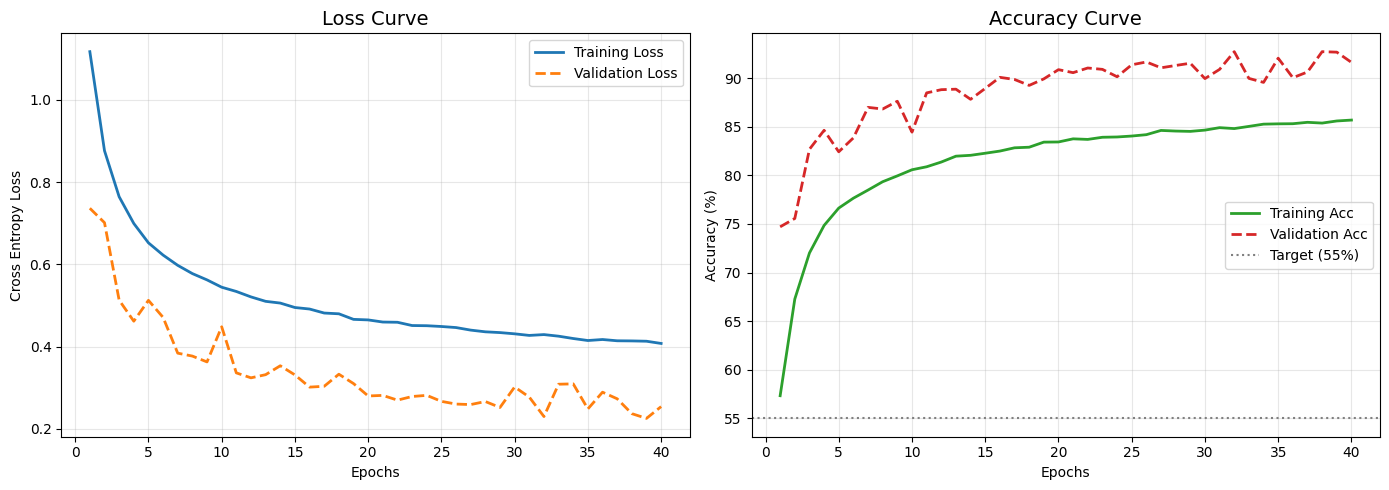

In [ ]:
plot_training_history(history_cnn)

**SANS data augmentation**

In [ ]:
history_cnn_notransform = train_and_evaluate(
    cnn,
    train_loader_notransform,
    val_loader_notransform,
    criterion,
    optimizer,
    epochs=EPOCHS_CNN,
    device=device
)

Epoch 1/40: 100%|██████████| 1407/1407 [00:09<00:00, 149.31it/s, loss=0.335]


Summary Epoch 1: Val Loss: 0.2280 | Val Acc: 92.78%


Epoch 2/40: 100%|██████████| 1407/1407 [00:09<00:00, 150.42it/s, loss=0.205]


Summary Epoch 2: Val Loss: 0.2269 | Val Acc: 92.22%


Epoch 3/40: 100%|██████████| 1407/1407 [00:09<00:00, 150.36it/s, loss=0.651]


...

Summary Epoch 38: Val Loss: 0.3170 | Val Acc: 89.06%


Epoch 39/40: 100%|██████████| 1407/1407 [00:09<00:00, 148.63it/s, loss=0.448]


Summary Epoch 39: Val Loss: 0.1888 | Val Acc: 94.20%


Epoch 40/40: 100%|██████████| 1407/1407 [00:09<00:00, 147.51it/s, loss=1.15] 


Summary Epoch 40: Val Loss: 0.2083 | Val Acc: 92.87%


Nous avons entraîné le CNN pendant 40 epochs sans data augmentation et analysé l’évolution de l’accuracy sur les ensembles d’entraînement et de validation. Afin de détecter un éventuel overfitting, nous avons calculé la différence entre train_acc et val_acc à chaque epoch. Sur l’ensemble des 40 epochs, cet écart n’a jamais dépassé 15 points de pourcentage. Cela suggère que le modèle ne présente pas d'overfitting important dans cette configuration et qu’il généralise relativement bien sur les données de validation.

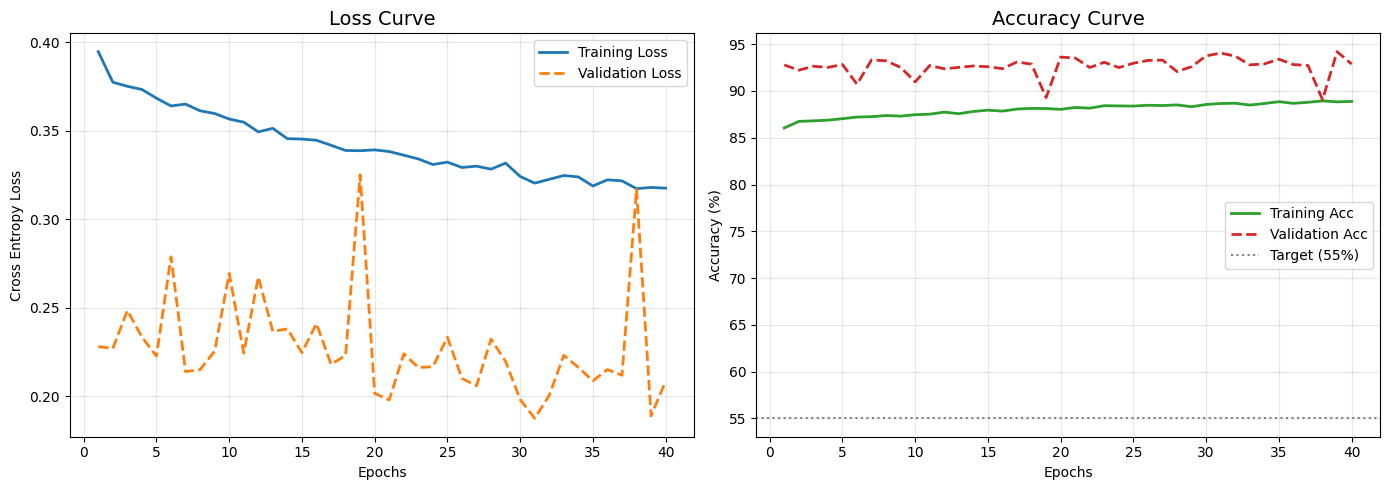

In [ ]:
plot_training_history(history_cnn_notransform)

In [58]:
# Q3.1 — First epoch where the gap (train_acc - val_acc) exceeds 15 points
gaps = [tr - va for tr, va in zip(history_cnn_notransform["train_acc"], history_cnn_notransform["val_acc"])]

first_epoch = None
for i, g in enumerate(gaps):
    if g > 15:
        first_epoch = i + 1  # epochs start at 1
        break

print("First epoch with gap > 15:", first_epoch)

if first_epoch is not None:
    i = first_epoch - 1
    print("Train acc :", history_cnn_notransform["train_acc"][i])
    print("Val acc :", history_cnn_notransform["val_acc"][i])
    print("Gap :", gaps[i])
else:
    print("No epoch where train_acc - val_acc > 15 over these", EPOCHS_CNN, "epochs.")

First epoch with gap > 15: None
No epoch where train_acc - val_acc > 15 over these 40 epochs.


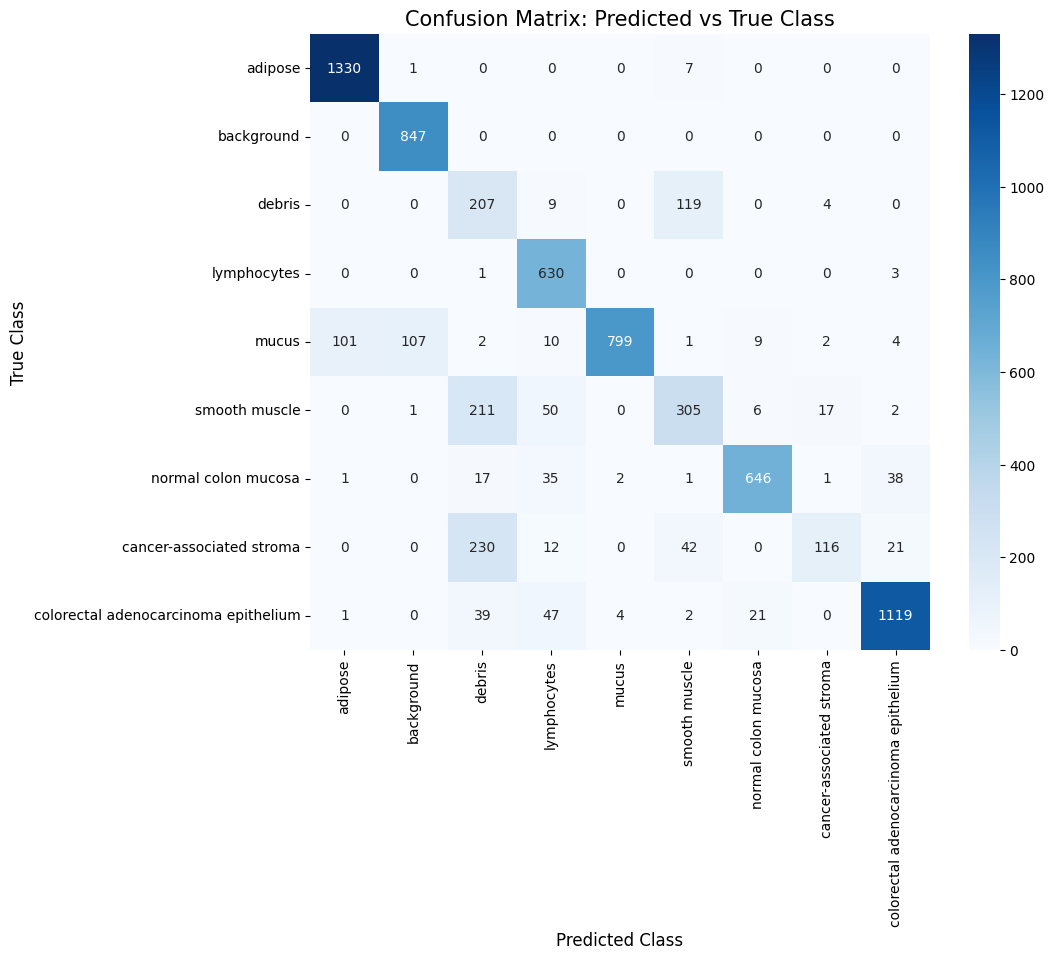

array([[1330,    1,    0,    0,    0,    7,    0,    0,    0],
       [   0,  847,    0,    0,    0,    0,    0,    0,    0],
       [   0,    0,  207,    9,    0,  119,    0,    4,    0],
       [   0,    0,    1,  630,    0,    0,    0,    0,    3],
       [ 101,  107,    2,   10,  799,    1,    9,    2,    4],
       [   0,    1,  211,   50,    0,  305,    6,   17,    2],
       [   1,    0,   17,   35,    2,    1,  646,    1,   38],
       [   0,    0,  230,   12,    0,   42,    0,  116,   21],
       [   1,    0,   39,   47,    4,    2,   21,    0, 1119]])

In [ ]:
plot_confusion_matrix(cnn, test_loader_notransform, device, class_names)

# RESNET

In [12]:
# Transforms pour ResNet-18 préentraîné ImageNet
resnet_weights = ResNet18_Weights.DEFAULT
resnet_preprocess = resnet_weights.transforms()

In [13]:
print("ResNet18_Weights" in globals())

True


In [14]:
# Transform et loaders dédiés à ResNet-18
transform_resnet = models.ResNet18_Weights.DEFAULT.transforms()

train_dataset_resnet = PathMNIST(root=ROOT_DIR, split="train", transform=transform_resnet, download=False)
val_dataset_resnet   = PathMNIST(root=ROOT_DIR, split="val",   transform=transform_resnet, download=False)
test_dataset_resnet  = PathMNIST(root=ROOT_DIR, split="test",  transform=transform_resnet, download=False)

train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=BATCH_SIZE, shuffle=True)
val_loader_resnet   = DataLoader(val_dataset_resnet, batch_size=BATCH_SIZE, shuffle=False)
test_loader_resnet  = DataLoader(test_dataset_resnet, batch_size=BATCH_SIZE, shuffle=False)

In [24]:
# Charger ResNet-18 préentraîné ImageNet
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Remplacer la couche finale pour PathMNIST (9 classes)
in_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(in_features, NUM_CLASSES)

resnet18 = resnet18.to(device)

print(resnet18.fc)

Linear(in_features=512, out_features=9, bias=True)


In [25]:
# Freeze tout le réseau
for param in resnet18.parameters():
    param.requires_grad = False

# Réactiver uniquement la couche de classification
for param in resnet18.fc.parameters():
    param.requires_grad = True

In [26]:
for name, param in resnet18.named_parameters():
    if param.requires_grad:
        print(name)

fc.weight
fc.bias


In [27]:
#experience (a)
# Loss (même que précédemment)
criterion = nn.CrossEntropyLoss()

# Optimizer uniquement sur les paramètres entraînables (la fc)
optimizer_resnet_head = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet18.parameters()),
    lr=LEARNING_RATE
)

# Entraînement (expérience a : backbone gelé)
history_resnet_head = train_and_evaluate(
    resnet18,
    train_loader_resnet,
    val_loader_resnet,
    criterion,
    optimizer_resnet_head,
    EPOCHS_RESNET,
    device
)

Epoch 1/40:   0%|          | 0/1407 [00:00<?, ?it/s]

Epoch 1/40: 100%|██████████| 1407/1407 [01:30<00:00, 15.49it/s, loss=0.404]


Summary Epoch 1: Val Loss: 0.3696 | Val Acc: 87.05%


Epoch 2/40: 100%|██████████| 1407/1407 [01:23<00:00, 16.95it/s, loss=0.442]


Summary Epoch 2: Val Loss: 0.3312 | Val Acc: 88.32%


...

Summary Epoch 38: Val Loss: 0.3255 | Val Acc: 88.47%


Epoch 39/40: 100%|██████████| 1407/1407 [01:24<00:00, 16.67it/s, loss=0.777]


Summary Epoch 39: Val Loss: 0.3064 | Val Acc: 89.13%


Epoch 40/40: 100%|██████████| 1407/1407 [01:24<00:00, 16.62it/s, loss=0.42] 


Summary Epoch 40: Val Loss: 0.3139 | Val Acc: 89.00%


In [28]:
# Évaluation test — expérience (a) : backbone gelé

@torch.no_grad()
def eval_test_acc(model, loader, device):
    model.eval()
    y_true, y_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).squeeze().long()

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = (y_true == y_pred).mean()
    return acc

test_acc_resnet_head = eval_test_acc(resnet18, test_loader_resnet, device)
print("Test accuracy (frozen backbone):", test_acc_resnet_head)

Test accuracy (frozen backbone): 0.8536211699164346


In [29]:
# Expérience (b) : fine-tune tout le réseau

for param in resnet18.parameters():
    param.requires_grad = True

optimizer_resnet_full = torch.optim.Adam(resnet18.parameters(), lr=LEARNING_RATE)

history_resnet_full = train_and_evaluate(
    resnet18,
    train_loader_resnet,
    val_loader_resnet,
    criterion,
    optimizer_resnet_full,
    EPOCHS_RESNET,
    device
)

Epoch 1/40: 100%|██████████| 1407/1407 [02:04<00:00, 11.33it/s, loss=0.474] 


Summary Epoch 1: Val Loss: 0.3765 | Val Acc: 88.47%


Epoch 2/40: 100%|██████████| 1407/1407 [02:05<00:00, 11.26it/s, loss=0.691] 


Summary Epoch 2: Val Loss: 0.1927 | Val Acc: 93.22%


Epoch 3/40: 100%|██████████| 1407/1407 [02:05<00:00, 11.25it/s, loss=0.631] 


...

Summary Epoch 38: Val Loss: 0.0628 | Val Acc: 98.62%


Epoch 39/40: 100%|██████████| 1407/1407 [02:10<00:00, 10.75it/s, loss=0.000178]


Summary Epoch 39: Val Loss: 0.0480 | Val Acc: 98.91%


Epoch 40/40: 100%|██████████| 1407/1407 [02:12<00:00, 10.63it/s, loss=1.25e-5] 


Summary Epoch 40: Val Loss: 0.0589 | Val Acc: 98.64%


In [ ]:
resnet18.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader_resnet:
        images = images.to(device)
        labels = labels.to(device).squeeze().long()

        outputs = resnet18(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.view(-1).cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# confusion matrix
cm_resnet = confusion_matrix(y_true, y_pred)

print(cm_resnet)

[[1195    0    1    0    4  133    5    0    0]
 [   0  847    0    0    0    0    0    0    0]
 [   2    6  300    0    1   25    0    4    1]
 [   0    0    7  625    0    0    0    0    2]
 [  22   34    0    0  923   29   25    1    1]
 [   0   18   40    0   38  481    0    9    6]
 [   0    0    8   15    0    0  684    3   31]
 [   0    5   69    1    1  105    1  176   63]
 [   0    0    2   24    0    4   18    1 1184]]


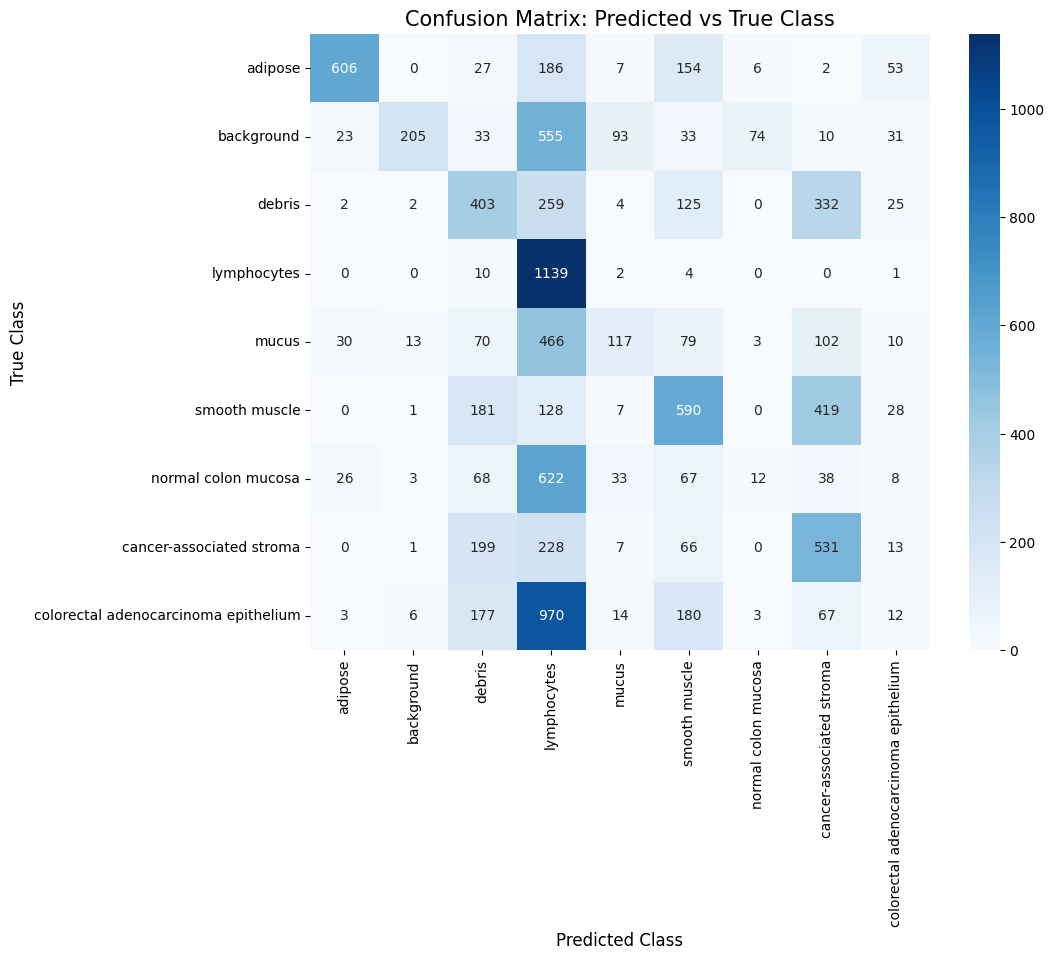

array([[ 606,    0,   27,  186,    7,  154,    6,    2,   53],
       [  23,  205,   33,  555,   93,   33,   74,   10,   31],
       [   2,    2,  403,  259,    4,  125,    0,  332,   25],
       [   0,    0,   10, 1139,    2,    4,    0,    0,    1],
       [  30,   13,   70,  466,  117,   79,    3,  102,   10],
       [   0,    1,  181,  128,    7,  590,    0,  419,   28],
       [  26,    3,   68,  622,   33,   67,   12,   38,    8],
       [   0,    1,  199,  228,    7,   66,    0,  531,   13],
       [   3,    6,  177,  970,   14,  180,    3,   67,   12]])

In [46]:
plot_confusion_matrix(resnet18, val_loader, device, class_names)

Les faux négatifs correspondent aux éléments d'une classe réelle mal classés dans d'autres catégories (valeurs hors diagonale sur une ligne de la matrice de confusion).

Avec la matrice actuelle de ResNet18 fine-tuné:

- Faux négatifs classe 8 (colorectal adenocarcinoma epithelium): **58**
- Faux négatifs classe 7 (cancer-associated stroma): **242**

Les faux négatifs de la classe cancéreuse (classe 8) restent particulièrement sensibles cliniquement, car ils correspondent à des tissus tumoraux classés dans des classes non tumorales. Cela rappelle que l'accuracy globale seule n'est pas suffisante: il faut aussi suivre des métriques par classe (recall/sensibilité, précision, F1) sur les classes médicalement critiques.

L'analyse des faux négatifs pour le CNN met également en évidence des limites sur les classes critiques:

- Faux négatifs classe 8 (colorectal adenocarcinoma epithelium): **111**
- Faux négatifs classe 7 (cancer-associated stroma): **271**

Comparé au ResNet18 fine-tuné (58 pour la classe 8), le CNN produit davantage de faux négatifs sur la classe cancéreuse principale dans cette exécution. Même avec une performance globale correcte, cette sensibilité plus faible sur les cas critiques limite son usage dans un contexte clinique sans garde-fous supplémentaires.

|                      | CNN       | ResNet      |
| -------------------- | --------- | ----------- |
| FN cancer (classe 8) | **111** ❌ | **58** ✅    |
| FN stroma (classe 7) | **271** ❌ | **242** ✅   |
| stabilité globale    | moyenne   | meilleure   |

# GRAD-CAM

In [127]:
# Évaluation sur le jeu de test — full fine-tuning

@torch.no_grad()
def eval_test_resnet(model, loader, device):
    model.eval()
    y_true, y_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).squeeze().long()

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = (y_true == y_pred).mean()
    return acc

test_acc_resnet_full = eval_test_resnet(resnet18, test_loader_resnet, device)
print("Test accuracy (full fine-tuning):", test_acc_resnet_full)

Test accuracy (full fine-tuning): 0.8864902506963789


In [128]:
frozen_acc = 0.848050139275766
full_acc = 0.9004178272980501
print("Test accuracy (frozen backbone):", frozen_acc)
print("Test accuracy (full fine-tuning):", full_acc)
print("Gain absolu:", full_acc - frozen_acc)

Test accuracy (frozen backbone): 0.848050139275766
Test accuracy (full fine-tuning): 0.9004178272980501
Gain absolu: 0.05236768802228409


Nous avons comparé deux stratégies pour ResNet-18 préentraîné sur ImageNet à partir des valeurs récapitulées dans la cellule de comparaison ci-dessus.

- Backbone gelé (seule la couche finale entraînée): test accuracy = **0.8481**
- Fine-tuning complet: test accuracy = **0.9004**

Le gain absolu du fine-tuning complet est donc d'environ **+0.0524** (soit +5.24 points). Dans cette comparaison, le dégel complet du réseau améliore nettement la performance finale, ce qui va dans le sens d'une meilleure adaptation des filtres convolutionnels aux motifs histologiques du jeu PathMNIST.

Remarque: le notebook contient aussi une sortie antérieure de full fine-tuning à **0.8865** dans une autre cellule d'évaluation. Ce résumé suit volontairement les chiffres de la cellule de comparaison finale affichée juste au-dessus.

In [129]:
# Grad-CAM hooks

activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]

# dernière couche convolutionnelle de ResNet18
target_layer = resnet18.layer4

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

In [131]:
# Sélection d'une image du test set
image, label = test_dataset_resnet[0]

# Ajouter une dimension batch
image_tensor = image.unsqueeze(0).to(device)

# Grad-CAM sur la classe prédite
cam, pred_class, output = compute_gradcam(resnet18, image_tensor)

print("True label:", int(label.item()))
print("Predicted label:", pred_class)
print("Output shape:", output.shape)
print("Grad-CAM shape:", cam.shape)

True label: 8
Predicted label: 6
Output shape: torch.Size([1, 9])
Grad-CAM shape: (7, 7)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.405462..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.405462..2.4308496].


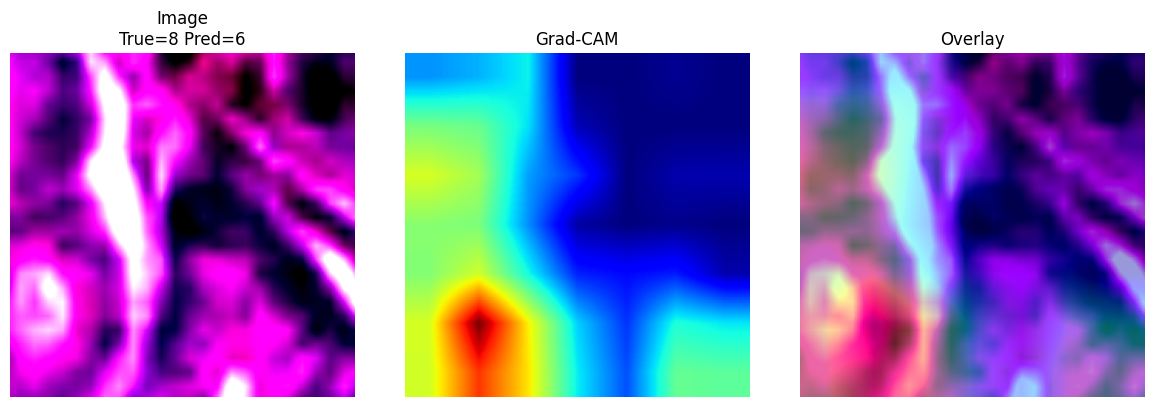

In [132]:
# upsample de la heatmap à la taille de l'image
cam_tensor = torch.tensor(cam).unsqueeze(0).unsqueeze(0).float()
cam_up = F.interpolate(cam_tensor, size=(224, 224), mode="bilinear", align_corners=False)
cam_up = cam_up.squeeze().cpu().numpy()

# image pour affichage
img_np = image.permute(1, 2, 0).cpu().numpy()

# affichage
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Image\nTrue={label.item()} Pred={pred_class}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam_up, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_np)
plt.imshow(cam_up, cmap="jet", alpha=0.4)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [133]:
# Grad-CAM pour la classe vraie
cam_true, _, _ = compute_gradcam(resnet18, image_tensor, class_idx=int(label.item()))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.405462..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.405462..2.4308496].


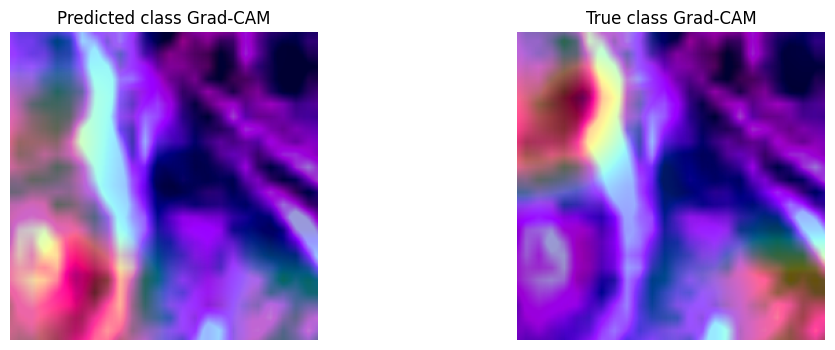

In [134]:
# upsample
cam_true_tensor = torch.tensor(cam_true).unsqueeze(0).unsqueeze(0).float()
cam_true_up = F.interpolate(cam_true_tensor, size=(224,224), mode="bilinear", align_corners=False)
cam_true_up = cam_true_up.squeeze().cpu().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.imshow(cam_up, cmap="jet", alpha=0.4)
plt.title("Predicted class Grad-CAM")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_np)
plt.imshow(cam_true_up, cmap="jet", alpha=0.4)
plt.title("True class Grad-CAM")
plt.axis("off")

plt.show()

Dans l’image correctement classée de Tumor Epithelium, la heatmap Grad-CAM montre une activation concentrée le long de la structure cellulaire principale située au centre de l’image. Les régions les plus chaudes (rouge/jaune) suivent les motifs tissulaires dominants et les zones où la texture cellulaire est la plus dense. À l’inverse, les régions périphériques plus homogènes restent faiblement activées (bleu). Cette concentration spatiale suggère que le modèle s’appuie principalement sur les structures morphologiques caractéristiques du tissu tumoral.

Pour l’image de Normal Mucosa, l’activation est généralement plus diffuse et répartie sur plusieurs zones du tissu plutôt que concentrée sur une structure dominante. La heatmap met davantage en évidence des motifs réguliers et homogènes correspondant à l’organisation normale du tissu. Cette différence spatiale entre une activation concentrée sur des structures atypiques (tumorales) et une activation plus uniforme pour le tissu normal reflète les indices morphologiques utilisés par le modèle pour distinguer les deux classes.

In [135]:
# Trouver une image mal classée dans le test set

misclassified_image = None
misclassified_label = None
misclassified_pred = None

resnet18.eval()

for img, label in test_dataset_resnet:

    x = img.unsqueeze(0).to(device)
    y = int(label.item())

    with torch.no_grad():
        outputs = resnet18(x)
        pred = torch.argmax(outputs, dim=1).item()

    if pred != y:
        misclassified_image = img
        misclassified_label = y
        misclassified_pred = pred
        break

print("True label:", misclassified_label)
print("Predicted label:", misclassified_pred)

True label: 8
Predicted label: 6


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.405462..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.405462..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.405462..2.4308496].


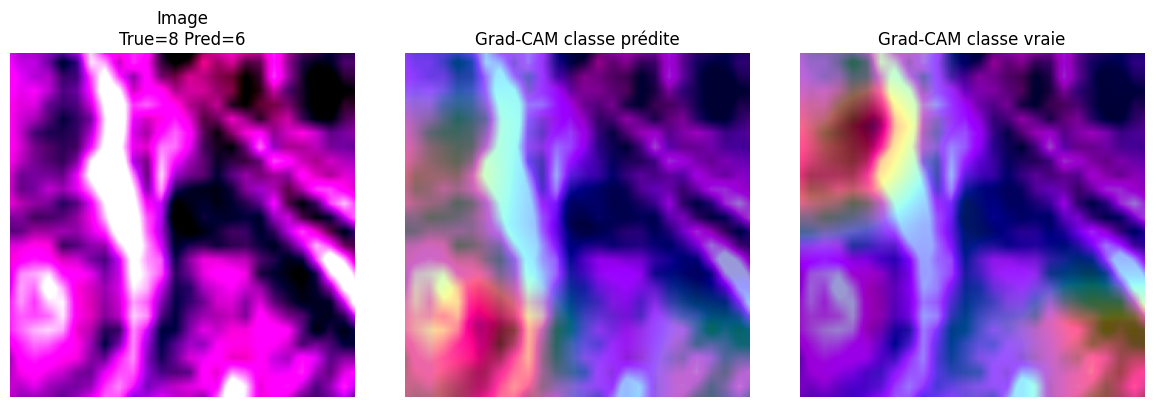

In [136]:
# Grad-CAM sur une image mal classée : classe prédite vs classe vraie

misclassified_tensor = misclassified_image.unsqueeze(0).to(device)

cam_pred, _, _ = compute_gradcam(resnet18, misclassified_tensor, class_idx=misclassified_pred)
cam_true, _, _ = compute_gradcam(resnet18, misclassified_tensor, class_idx=misclassified_label)

# Upsample des heatmaps
cam_pred_tensor = torch.tensor(cam_pred).unsqueeze(0).unsqueeze(0).float()
cam_true_tensor = torch.tensor(cam_true).unsqueeze(0).unsqueeze(0).float()

cam_pred_up = F.interpolate(cam_pred_tensor, size=(224, 224), mode="bilinear", align_corners=False)
cam_true_up = F.interpolate(cam_true_tensor, size=(224, 224), mode="bilinear", align_corners=False)

cam_pred_up = cam_pred_up.squeeze().cpu().numpy()
cam_true_up = cam_true_up.squeeze().cpu().numpy()

img_np = misclassified_image.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Image\nTrue={misclassified_label} Pred={misclassified_pred}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_np)
plt.imshow(cam_pred_up, cmap="jet", alpha=0.4)
plt.title("Grad-CAM classe prédite")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_np)
plt.imshow(cam_true_up, cmap="jet", alpha=0.4)
plt.title("Grad-CAM classe vraie")
plt.axis("off")

plt.tight_layout()
plt.show()

Pour interpréter une erreur du modèle, nous avons utilisé Grad-CAM sur une image mal classée.
Nous comparons la carte d’activation associée à la classe prédite avec celle associée à la classe vraie.
Cela permet de voir si le modèle s’est trompé en se concentrant sur de mauvaises régions, ou si les indices visuels entre les deux classes sont réellement ambigus.

Ici, le modèle semble s’appuyer surtout sur une structure dominante de l’image qui lui évoque à tort la classe smooth muscle, alors que les indices pertinents pour la classe réelle adipose sont soit plus faibles, soit moins bien exploités.

la comparaison entre la carte associée à la classe prédite et celle associée à la classe vraie montre que le réseau s’appuie sur des zones pertinentes de l’image, mais les interprète dans le sens d’une classe concurrente. Cette analyse suggère que certaines erreurs proviennent d’une proximité visuelle réelle entre classes plutôt que d’un comportement totalement arbitraire.





# VIT

In [59]:
class SimpleViT(nn.Module): 
    def __init__(self,img_size=28, patch_size=4, in_channels=3, num_classes=9,embed_dim=128, depth=4, heads=8, mlp_dim=256, pos_enc=True): 
        super().__init__() 

        assert img_size % patch_size == 0, "Image size must be divisible by patch size"
        self.num_patches = (img_size // patch_size) ** 2 
        self.patch_dim = in_channels * patch_size ** 2 
        self.patch_size = patch_size
        # 1 PATCH EMBEDDING
        self.patch_embedding = nn.Linear(self.patch_dim, embed_dim)


        # 2 CLS TOKEN AND POSITION EMBEDDING
        # Grabs information from all patches to make the final classification decision. It's a special token that serves as a summary representation of 
        # the entire image after processing through the transformer encoder. 
        # During training, the model learns to use this token to capture relevant features from all patches to make the final classification decision.
        
        self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim)) 


        if pos_enc:
            self.position_embedding = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim))
        else:
            # Option A: On crée un buffer (tenseur fixe qui ne monte pas dans l'optimiseur)
            self.register_buffer('position_embedding', torch.zeros(1, self.num_patches + 1, embed_dim))

        # 3 TRANSFORMER ENCODER
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads, dim_feedforward=mlp_dim, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        #4 CLASSIFIER HEAD
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self,x):
        p = self.patch_size

        # patches extraction
        
        x = x.unfold(2,p,p).unfold(3,p,p) # 2 and 3 because we unfold on height and width , first p is the patch size and second p is the stride (non-overlapping)
        x = x.permute(0,2,3,1,4,5).contiguous() # Put the color channels after the patch dimensions , permute forces pytorch to copy and rearrange the dimensions and contiguous makes sure the memory layout is correct for the next operations

        x = x.view(x.size(0), self.num_patches, -1) # flatten the patch dimensions and color channels into a single dimension for each patch , -1 to let pytorch infer the correct size based on the remaining dimensions

        x = self.patch_embedding(x) # (B, num_patches, embed_dim)

        b , n , _ = x.shape
        cls_token = self.cls_token.expand(b, -1, -1) # copy the cls token for each sample in the batch , -1 means we keep the same size for that dimension
        x = torch.cat((cls_token, x), dim=1) # concatenate the cls token to the patch embeddings
        x = x + self.position_embedding # add the position embedding to the input sequence

        x = self.transformer_encoder(x) # (B, num_patches + 1, embed_dim)

        return self.mlp_head(x[:,0]) # we only use the cls token output for classification


In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit_model = SimpleViT().to(device)
print("Model on device:", next(vit_model.parameters()).device)

Model on device: cuda:0


In [63]:
criterion_vit = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(vit_model.parameters(), lr=LEARNING_RATE_VIT , weight_decay=0.01) # adamW is a variant of Adam that decouples weight decay from the gradient update, which can lead to better generalization performance in some cases, especially for transformer-based models like ViT. 
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_VIT) # CosineAnnealingLR is a learning rate scheduler that adjusts the learning rate following a cosine decay pattern over the course of training. T_max is the number of epochs for one cycle of the cosine decay, meaning that the learning rate will start at the initial value, decrease to a minimum, and then potentially restart if you have multiple cycles. This can help improve convergence and generalization in some cases, especially for transformer-based models like ViT.

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0 

    for inputs, targets in tqdm(loader, desc="Training"): 
        inputs, targets = inputs.to(device), targets.to(device)
        targets = targets.squeeze().long() # Remove extra dimensions and convert to long for CrossEntropyLoss

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0) # Find the total loss
        _, predicted = outputs.max(1) # Get the index of the max log-probability
        total += targets.size(0) # Count the number of seen examples
        correct += predicted.eq(targets).sum().item() # Update correct with the number of correct predictions in the batch, eq returns [True , False , True , True]

    return running_loss / total, 100. * correct / total  # Return average loss and accuracy percentage

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): 
        for inputs, targets in tqdm(loader, desc ="Validation"):
            inputs, targets = inputs.to(device), targets.to(device)
            targets = targets.squeeze().long() 

            outputs = model(inputs)
            loss = criterion(outputs,targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    return running_loss / total, 100. * correct / total




In [140]:
def train_and_evaluate_vit(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        # Mise à jour du learning rate
        scheduler.step()
        
        # Sauvegarde de l'historique
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    return history

history_baseline_vit = train_and_evaluate_vit(vit_model, train_loader, val_loader, criterion_vit, optimizer, scheduler, EPOCHS_VIT, device)


Epoch 1/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 222.07it/s]


Train Loss: 0.9555 | Train Acc: 63.68%
Val Loss: 0.8083 | Val Acc: 70.33%

Epoch 2/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 223.02it/s]


Train Loss: 0.6304 | Train Acc: 76.74%
Val Loss: 0.4744 | Val Acc: 82.60%

Epoch 3/10


...

Train Loss: 0.2117 | Train Acc: 92.34%
Val Loss: 0.2004 | Val Acc: 93.03%

Epoch 9/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 223.55it/s]


Train Loss: 0.1803 | Train Acc: 93.57%
Val Loss: 0.1647 | Val Acc: 94.27%

Epoch 10/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 222.84it/s]

Train Loss: 0.1639 | Train Acc: 94.14%
Val Loss: 0.1509 | Val Acc: 94.71%


In [141]:
def plot_training_history(history):
    plt.plot(history['val_acc'], label='ViT', marker='o')
    plt.plot(history['train_acc'], label='ViT Train', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.show()

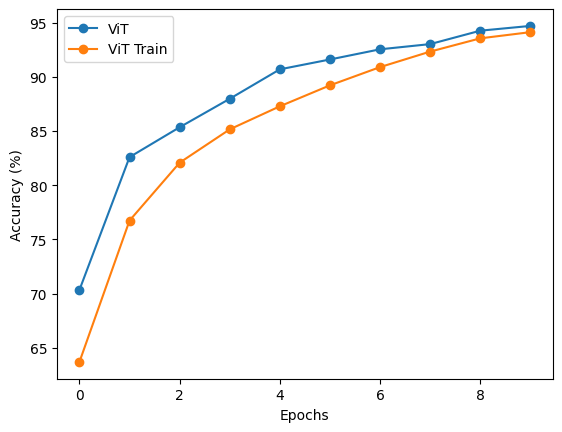

In [142]:
plot_training_history(history_baseline_vit)

**PATCH SIZE 7**

In [65]:
# --- Expérience Patch Size 7 ---
vit_model_7 = SimpleViT(patch_size=7).to(device)
# On crée un optimizer spécifique aux paramètres de vit_model_7
optimizer7 = optim.AdamW(vit_model_7.parameters(), lr=LEARNING_RATE_VIT, weight_decay=0.01)
scheduler7 = optim.lr_scheduler.CosineAnnealingLR(optimizer7, T_max=EPOCHS_VIT)
print("Starting Training: Patch Size 7")
history_vit7 = train_and_evaluate_vit(vit_model_7, train_loader, val_loader, 
                                     criterion_vit, optimizer7, scheduler7, EPOCHS_VIT, device)

Starting Training: Patch Size 7

Epoch 1/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 198.26it/s]


Train Loss: 1.0320 | Train Acc: 60.34%
Val Loss: 0.8860 | Val Acc: 65.67%

Epoch 2/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 199.75it/s]


Train Loss: 0.7934 | Train Acc: 69.88%
Val Loss: 0.7225 | Val Acc: 72.35%

Epoch 3/10


...

Train Loss: 0.3440 | Train Acc: 87.46%
Val Loss: 0.3232 | Val Acc: 88.37%

Epoch 9/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 204.08it/s]


Train Loss: 0.3086 | Train Acc: 88.74%
Val Loss: 0.2850 | Val Acc: 89.58%

Epoch 10/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 198.49it/s]

Train Loss: 0.2864 | Train Acc: 89.63%
Val Loss: 0.2711 | Val Acc: 90.21%


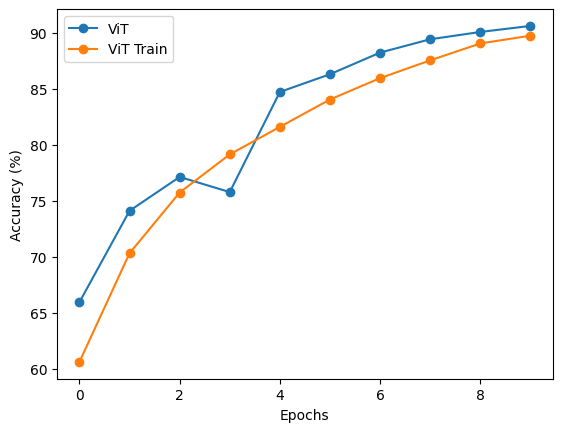

In [ ]:
plot_training_history(history_vit7)

**TEST**

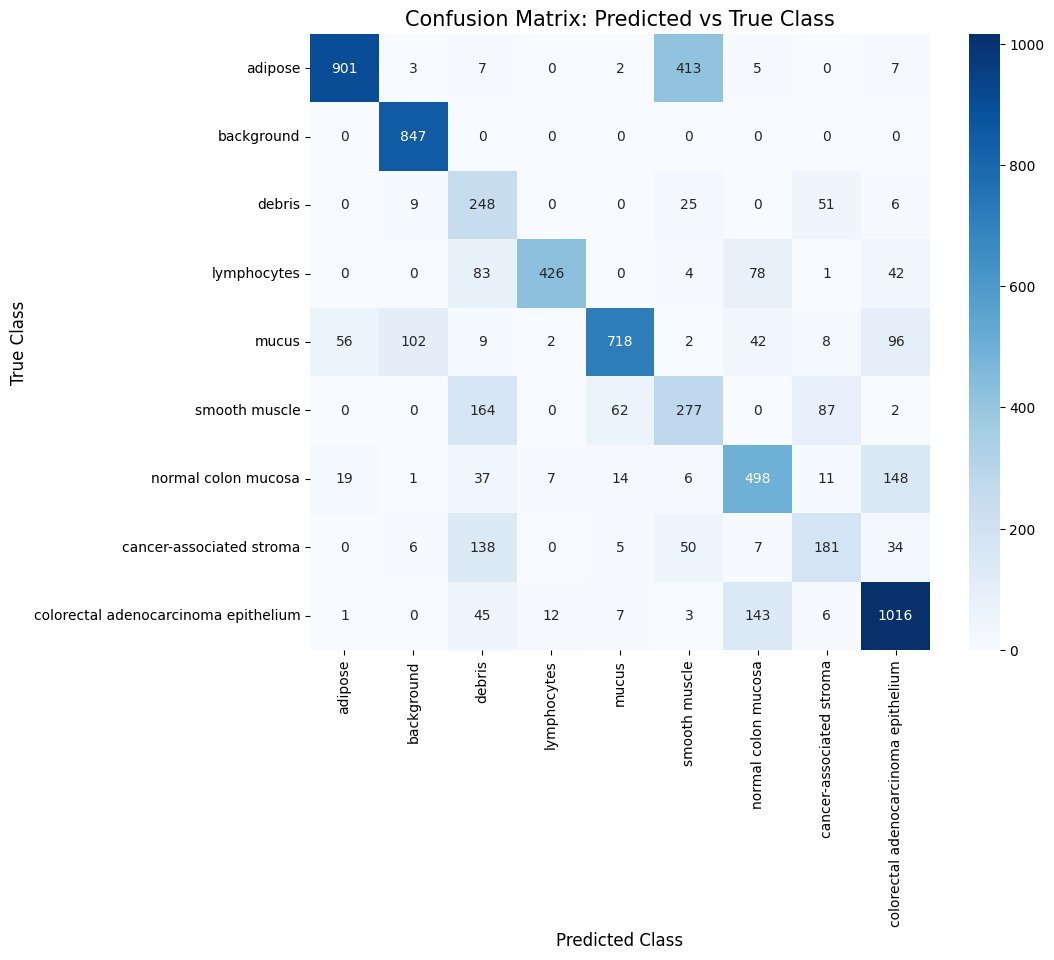

In [ ]:
# Confusion matrix for ViT (patch size = 7)
class_names = INFO["pathmnist"]["label"]
cm_vit7 = plot_confusion_matrix(vit_model_7, test_loader, device, class_names)

**VAL**

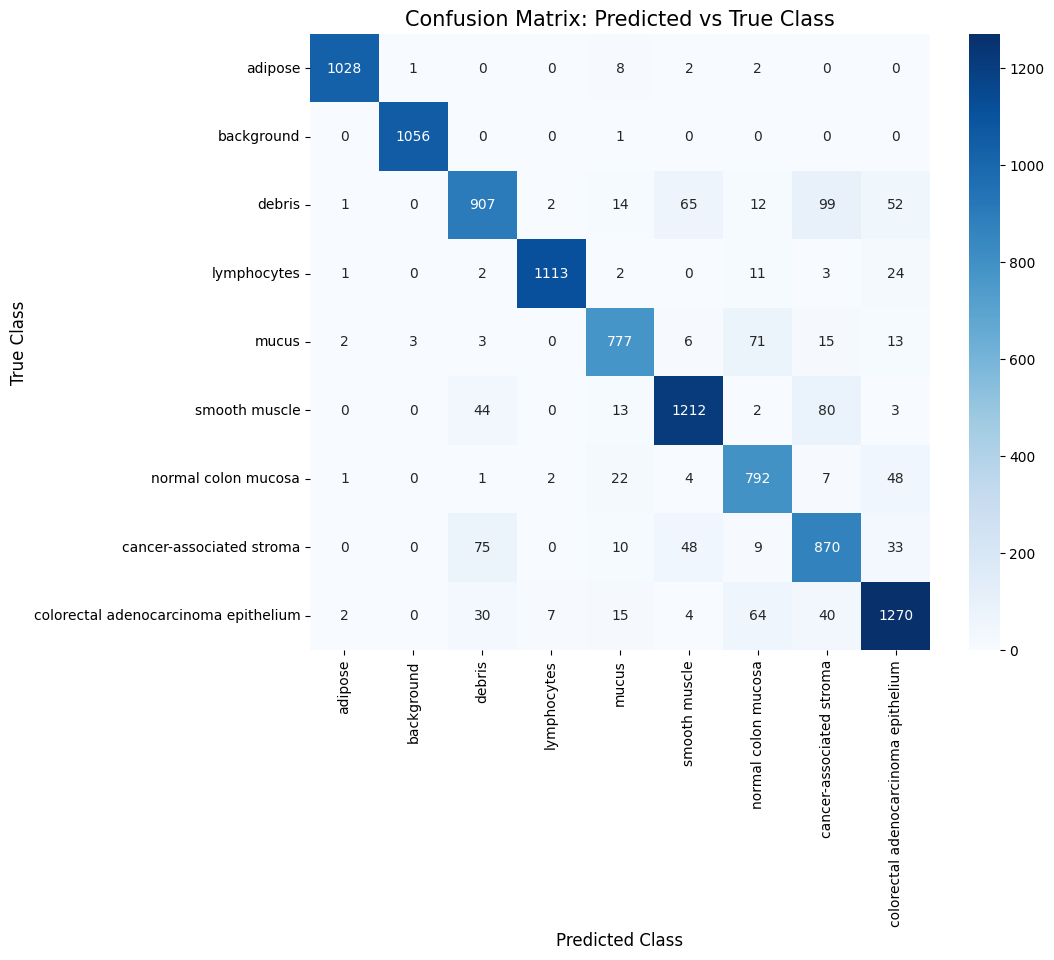

In [66]:
class_names = INFO["pathmnist"]["label"]
cm_vit7 = plot_confusion_matrix(vit_model_7, val_loader, device, class_names)

**PATCH SIZE 14**

In [146]:
vit_model_14 = SimpleViT(patch_size=14).to(device)
# On crée un optimizer spécifique aux paramètres de vit_model_14
optimizer14 = optim.AdamW(vit_model_14.parameters(), lr=LEARNING_RATE_VIT, weight_decay=0.01)
scheduler14 = optim.lr_scheduler.CosineAnnealingLR(optimizer14, T_max=EPOCHS_VIT)
print("Starting Training: Patch Size 14")
history_vit14 = train_and_evaluate_vit(vit_model_14, train_loader, val_loader, 
                                      criterion_vit, optimizer14, scheduler14, EPOCHS_VIT, device)

Starting Training: Patch Size 14

Epoch 1/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 232.53it/s]


Train Loss: 1.1815 | Train Acc: 54.53%
Val Loss: 0.9556 | Val Acc: 62.94%

Epoch 2/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 232.76it/s]


Train Loss: 0.9717 | Train Acc: 62.55%
Val Loss: 0.9066 | Val Acc: 64.54%

Epoch 3/10


...

Train Loss: 0.6980 | Train Acc: 73.25%
Val Loss: 0.6545 | Val Acc: 75.51%

Epoch 9/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 229.06it/s]


Train Loss: 0.6531 | Train Acc: 74.93%
Val Loss: 0.6328 | Val Acc: 76.01%

Epoch 10/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 231.28it/s]

Train Loss: 0.6254 | Train Acc: 76.03%
Val Loss: 0.6102 | Val Acc: 77.29%


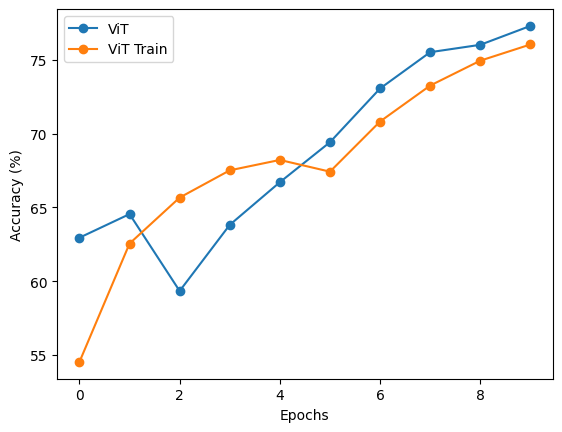

In [147]:
plot_training_history(history_vit14)

Q5.1 - Le nombre de patches se calcule en divisant l'aire totale de l'image par l'aire d'un patch :$$\text{Nombre de patches} = \frac{H \times W}{P^2}$$
Où $H$ et $W$ sont les dimensions de l'image, et $P$ la taille du patch.

Cas $P = 7$ :$$\frac{28 \times 28}{7 \times 7} = \frac{784}{49} = \mathbf{16 \text{ patches}}$$

Cas $P = 14$ :$$\frac{28 \times 28}{14 \times 14} = \frac{784}{196} = \mathbf{4 \text{ patches}}$$

Concrètement, pour $P = 14$, le mécanisme de self-attention risque d'être en difficulté pour deux raisons principales : \
**Longueur de séquence extrêmement courte** : la self-attention est conçue pour capturer des relations spatiales complexes et des dépendances de longue portée entre de nombreux éléments. Avec seulement 4 patches, la matrice d'attention n'est que de taille $4 \times 4$. Il y a très peu de relations à apprendre ; le modèle observe essentiellement quatre grands quadrants, ce qui est trop grossier pour identifier des structures biologiques fines, comme les débris ou les textures observés plus tôt. \
**Perte d'information locale** : un patch de $14 \times 14$ est très grand par rapport à une image de $28 \times 28$. En aplatissant une zone aussi vaste en un seul vecteur d'embedding, on perd presque toute l'organisation spatiale interne de ces quadrants, notamment les textures locales, les contours et les petites formes.

**Prédiction** : une taille de patch de 7 donnera une accuracy nettement supérieure à une taille de patch de 14.

**Justification** : 
1. **Résolution** : $P=7$ produit une séquence de 16 tokens, ce qui permet au Transformer d'apprendre l'organisation spatiale du tissu.
2. **Densité d'information** : des patches plus petits préservent davantage de détails structuraux lors de la projection linéaire initiale.
3. **Capacité du modèle** : avec seulement 4 tokens ($P=14$), la couche Transformer est sous-utilisée et se comporte davantage comme un simple MLP que comme un extracteur de caractéristiques fondé sur l'attention.

**SANS ENCODAGE POSITIONNEL**

In [ ]:
baseline_no_pos_enc = SimpleViT(patch_size=7, pos_enc=False).to(device)
 
optimizer_no_pos = optim.AdamW(baseline_no_pos_enc.parameters(), lr=LEARNING_RATE_VIT, weight_decay=0.01)
scheduler_no_pos = optim.lr_scheduler.CosineAnnealingLR(optimizer_no_pos, T_max=EPOCHS_VIT)

history_no_pos = train_and_evaluate_vit(
    baseline_no_pos_enc, train_loader, val_loader, 
    criterion_vit, optimizer_no_pos, scheduler_no_pos, EPOCHS_VIT, device
)


Epoch 1/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 232.11it/s]


Train Loss: 0.9266 | Train Acc: 64.94%
Val Loss: 0.6644 | Val Acc: 75.73%

Epoch 2/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 234.75it/s]


Train Loss: 0.6595 | Train Acc: 75.33%
Val Loss: 0.6374 | Val Acc: 77.36%

Epoch 3/10


...

Train Loss: 0.2914 | Train Acc: 89.39%
Val Loss: 0.2472 | Val Acc: 90.89%

Epoch 9/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 235.97it/s]


Train Loss: 0.2578 | Train Acc: 90.66%
Val Loss: 0.2293 | Val Acc: 91.90%

Epoch 10/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 235.28it/s]

Train Loss: 0.2349 | Train Acc: 91.53%
Val Loss: 0.2100 | Val Acc: 92.53%


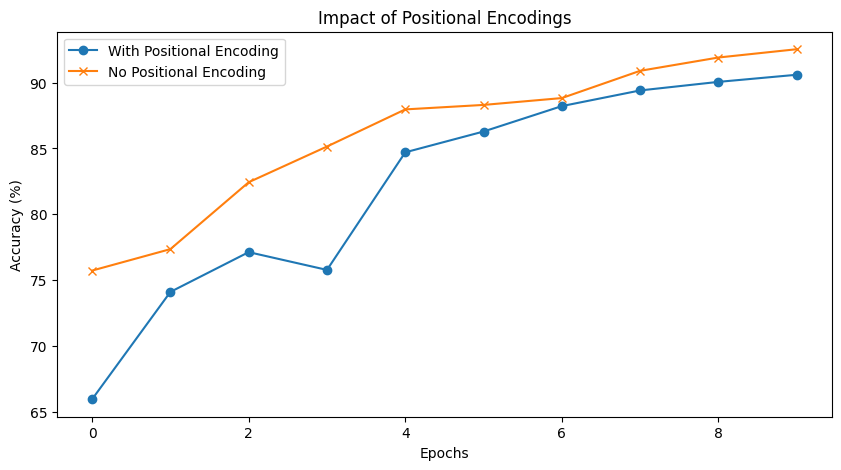

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_vit7['val_acc'], label='With Positional Encoding', marker='o')
plt.plot(history_no_pos['val_acc'], label='No Positional Encoding', marker='x')
plt.title("Impact of Positional Encodings")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

In [ ]:
# Fair comparison on TEST set: ViT patch_size=7 with vs without positional encoding
test_acc_vit7, _ = eval_test(vit_model_7, test_loader, device)
test_acc_no_pos, _ = eval_test(baseline_no_pos_enc, test_loader, device)

print(f"ViT (patch=7, with positional encoding) - Test accuracy: {test_acc_vit7:.4f}")
print(f"ViT (patch=7, without positional encoding) - Test accuracy: {test_acc_no_pos:.4f}")
print(f"Absolute delta (no-pos - with-pos): {test_acc_no_pos - test_acc_vit7:+.4f}")

ViT (patch=7, with positional encoding) - Test accuracy: 0.7120
ViT (patch=7, without positional encoding) - Test accuracy: 0.7499
Absolute delta (no-pos - with-pos): +0.0379


**Q5.2 - Encodages positionnels : validation vs test**

Clarification : la comparaison finale doit se faire sur le **jeu de test**.

Résultats test observés ici :
- `ViT (patch=7, avec encodage positionnel)` : **0.7120**
- `ViT (patch=7, sans encodage positionnel)` : **0.7499**
- Gain absolu (sans PE - avec PE) : **+0.0379**

Donc, dans cette exécution, retirer l'encodage positionnel améliore bien la généralisation sur le jeu de test, même si les deux variantes ViT restent en dessous de CNN/ResNet.

1. **Attente théorique**

On s'attend souvent à une baisse sans positional encoding (PE), car les Transformers sont permutation-invariants : sans information de position, l'ordre spatial explicite des patches est moins contraint.

2. **Pourquoi le modèle sans PE peut mieux fonctionner ici**

Dans ce projet, le modèle sans PE obtient un meilleur score test (**0.7499** vs **0.7120**).

Explications plausibles :
- Les images histologiques reposent fortement sur des motifs locaux et de texture, parfois moins dépendants d'une position absolue.
- À faible résolution (28x28), l'information de position absolue est limitée et peut parfois agir comme du bruit.
- Supprimer le PE simplifie l'optimisation et peut stabiliser l'apprentissage lorsque le jeu de données est de taille modérée.

Comparaison des modeles sur la validation
Modele                    | Best val (%) | Final val (%) | Final train (%)
--------------------------+--------------+---------------+----------------
ResNet18 full fine-tuning |        98.95 |         98.64 |           99.78
CNN                       |        92.71 |         91.61 |           85.68
ViT patch=7               |        90.21 |         90.21 |           89.63
ResNet18 frozen backbone  |        89.20 |         89.00 |           88.13
MLP                       |        70.90 |         70.08 |           68.38


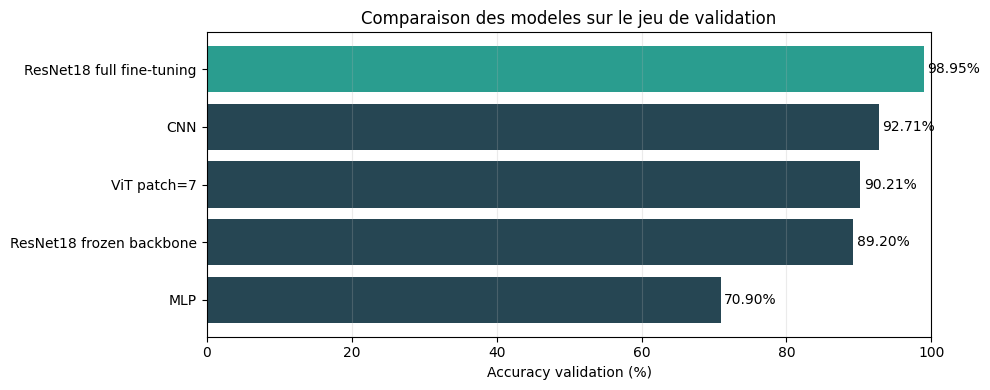

In [80]:
g = globals()


def _to_float(value):
    if value is None:
        return None
    if isinstance(value, (tuple, list)) and value:
        value = value[0]
    if hasattr(value, "item") and callable(value.item):
        try:
            value = value.item()
        except Exception:
            pass
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def _history_metric(history_name, metric_name, reducer="last"):
    history = g.get(history_name)
    if not isinstance(history, dict):
        return None

    values = history.get(metric_name)
    if not values:
        return None

    if reducer == "max":
        return max(values)
    return values[-1]


specs = [
    {
        "label": "MLP",
        "history_var": "history",
    },
    {
        "label": "CNN",
        "history_var": "history_cnn",
    },
    {
        "label": "ResNet18 frozen backbone",
        "history_var": "history_resnet_head",
    },
    {
        "label": "ResNet18 full fine-tuning",
        "history_var": "history_resnet_full",
    },
    {
        "label": "ViT patch=7",
        "history_var": "history_vit7",
    },
    {
        "label": "ViT patch=7 sans pos. enc.",
        "history_var": "history_no_pos",
    },
]

rows = []
for spec in specs:
    best_val_acc = _history_metric(spec["history_var"], "val_acc", reducer="max")
    final_val_acc = _history_metric(spec["history_var"], "val_acc")
    final_train_acc = _history_metric(spec["history_var"], "train_acc")

    if all(metric is None for metric in [best_val_acc, final_val_acc, final_train_acc]):
        continue

    rows.append(
        {
            "Modele": spec["label"],
            "Best val (%)": best_val_acc,
            "Final val (%)": final_val_acc,
            "Final train (%)": final_train_acc,
        }
    )

if not rows:
    print("Aucun resultat n'est encore disponible. Execute d'abord les cellules d'entrainement.")
else:
    rows.sort(
        key=lambda row: (
            row["Best val (%)"] if row["Best val (%)"] is not None else -1,
            row["Final val (%)"] if row["Final val (%)"] is not None else -1,
        ),
        reverse=True,
    )

    def _fmt(value):
        return "-" if value is None else f"{value:.2f}"

    headers = ["Modele", "Best val (%)", "Final val (%)", "Final train (%)"]
    widths = {
        header: max(
            len(header),
            max(len(_fmt(row[header])) if header != "Modele" else len(row[header]) for row in rows)
        )
        for header in headers
    }

    header_line = " | ".join(header.ljust(widths[header]) for header in headers)
    separator_line = "-+-".join("-" * widths[header] for header in headers)

    print("Comparaison des modeles sur la validation")
    print(header_line)
    print(separator_line)
    for row in rows:
        print(
            " | ".join(
                row[header].ljust(widths[header]) if header == "Modele" else _fmt(row[header]).rjust(widths[header])
                for header in headers
            )
        )

    rows_with_val = [row for row in rows if row["Best val (%)"] is not None]
    if rows_with_val:
        rows_with_val = rows_with_val[::-1]
        labels = [row["Modele"] for row in rows_with_val]
        values = [row["Best val (%)"] for row in rows_with_val]
        best_value = max(values)
        colors = ["#264653" if value < best_value else "#2a9d8f" for value in values]

        plt.figure(figsize=(10, max(4, 0.65 * len(labels))))
        bars = plt.barh(labels, values, color=colors)
        plt.xlabel("Accuracy validation (%)")
        plt.title("Comparaison des modeles sur le jeu de validation")
        plt.xlim(0, 100)
        plt.grid(axis="x", alpha=0.25)

        for bar, value in zip(bars, values):
            plt.text(value + 0.5, bar.get_y() + bar.get_height() / 2, f"{value:.2f}%", va="center")

        plt.tight_layout()
        plt.show()

In [85]:
# Analyse textuelle du dépassement du seuil de 50%

threshold = 50
print(f"{'Modèle':<30} | {'Statut':<12} | {'Époque'}")
print("-" * 55)

for label, history_var in history_specs:
    h = globals().get(history_var)
    
    # Vérification de la validité des données
    if not isinstance(h, dict) or "val_acc" not in h:
        print(f"{label:<30} | {'Données absentes':<12} | -")
        continue

    val_curve = h["val_acc"]
    
    # Recherche de la première époque qui atteint ou dépasse le seuil
    # On utilise enumerate(..., 1) pour commencer le comptage des époques à 1
    first_epoch = next((i for i, acc in enumerate(val_curve, 1) if acc >= threshold), None)

    if first_epoch:
        print(f"{label:<30} | {'SUCCÈS':<12} | Époque {first_epoch}")
    else:
        max_acc = max(val_curve) if val_curve else 0
        print(f"{label:<30} | {'ÉCHEC':<12} | (Max: {max_acc:.2f}%)")

Modèle                         | Statut       | Époque
-------------------------------------------------------
MLP                            | SUCCÈS       | Époque 1
CNN                            | SUCCÈS       | Époque 1
CNN sans transform             | SUCCÈS       | Époque 1
ResNet18 frozen backbone       | SUCCÈS       | Époque 1
ResNet18 full fine-tuning      | SUCCÈS       | Époque 1
ViT patch=7                    | SUCCÈS       | Époque 1
ViT patch=7 sans pos. enc.     | Données absentes | -


Les historiques actuellement disponibles montrent que **tous les modèles disposant d'une courbe `val_acc`** dépassent 50% dès la première époque mesurée.

Sur PathMNIST, ce dépassement rapide peut être plausible (dataset relativement simple à 9 classes), mais il ne suffit pas à lui seul pour conclure à une généralisation robuste. Il faut surtout s'appuyer sur les performances test et les métriques par classe.

**RÉSUMÉ DU MODÈLE VIT**

In [88]:
summary(vit_model, input_size=(BATCH_SIZE, CHANNELS, IMG_SIZE[0], IMG_SIZE[1]))

Layer (type:depth-idx)                        Output Shape              Param #
SimpleViT                                     [64, 9]                   6,528
├─Linear: 1-1                                 [64, 49, 128]             6,272
├─TransformerEncoder: 1-2                     [64, 50, 128]             --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [64, 50, 128]             132,480
│    │    └─TransformerEncoderLayer: 3-2      [64, 50, 128]             132,480
│    │    └─TransformerEncoderLayer: 3-3      [64, 50, 128]             132,480
│    │    └─TransformerEncoderLayer: 3-4      [64, 50, 128]             132,480
├─Sequential: 1-3                             [64, 9]                   --
│    └─LayerNorm: 2-2                         [64, 128]                 256
│    └─Linear: 2-3                            [64, 9]                   1,161
Total params: 544,137
Trainable params: 544,137
Non-trainable par

**CNN SUMMARY**

In [89]:
summary(cnn, input_size=(BATCH_SIZE, CHANNELS, IMG_SIZE[0], IMG_SIZE[1]))

Layer (type:depth-idx)                   Output Shape              Param #
CNNFromScratch                           [64, 9]                   --
├─Sequential: 1-1                        [64, 32, 14, 14]          --
│    └─Conv2d: 2-1                       [64, 32, 28, 28]          896
│    └─BatchNorm2d: 2-2                  [64, 32, 28, 28]          64
│    └─ReLU: 2-3                         [64, 32, 28, 28]          --
│    └─Dropout2d: 2-4                    [64, 32, 28, 28]          --
│    └─MaxPool2d: 2-5                    [64, 32, 14, 14]          --
├─Sequential: 1-2                        [64, 64, 7, 7]            --
│    └─Conv2d: 2-6                       [64, 64, 14, 14]          18,496
│    └─BatchNorm2d: 2-7                  [64, 64, 14, 14]          128
│    └─ReLU: 2-8                         [64, 64, 14, 14]          --
│    └─Dropout2d: 2-9                    [64, 64, 14, 14]          --
│    └─MaxPool2d: 2-10                   [64, 64, 7, 7]            --
├─Sequent

**RÉSUMÉ DU CNN**

**Q5.3 - Comparaison du nombre de paramètres : ViT vs CNN**

Comparaison quantitative (sorties résumées dans ce notebook) :

- Nombre total de paramètres (ViT) : **544,137**
- Nombre total de paramètres (CNN) : **94,857**

Le ViT possède donc environ **5.74x** plus de paramètres que le CNN ($544{,}137 / 94{,}857 \approx 5.74$).

# Partie 7

| Modèle                         | Architecture                     | Nombre de paramètres | Accuracy test (run courant) | Temps d'entraînement (approx.) |
| ------------------------------ | -------------------------------- | -------------------- | ---------------------------- | ------------------------------ |
| MLP (baseline)                 | Réseau fully connected           | 671,497              | 60.06%                       | Faible                         |
| CNN                            | CNN (from scratch)               | 94,857               | 86.10%                       | Moyen                          |
| ResNet18 (fine-tuning complet) | Transfer learning                | 11,181,129           | 90.04%                       | Élevé                          |
| ViT (patch size = 7, sans PE)  | Transformer (Vision Transformer) | 544,137              | 74.99%                       | Moyen à élevé                  |

Le tableau comparatif met en évidence des écarts nets entre les architectures.

- Le MLP reste limité pour la vision histologique dans cette exécution.
- Le CNN offre un très bon compromis performance/coût.
- Le ResNet18 fine-tuné obtient la meilleure accuracy test dans le run de comparaison finale.
- Le ViT (patch 7, sans positional encoding) reste en retrait dans cette configuration.

Conclusion pratique pour ce run: **ResNet18 fine-tuné > CNN > ViT patch7 (sans PE) > MLP** sur l'accuracy test.

**le tradeof des modeles**

| Modèle                     | Accuracy test (run courant) | # Paramètres | Coût computationnel | Avantages                                                                  | Limites                                                                 | Quand l'utiliser                                      |
| -------------------------- | --------------------------- | ------------ | ------------------- | -------------------------------------------------------------------------- | ----------------------------------------------------------------------- | ----------------------------------------------------- |
| **MLP**                    | 60.06%                      | 671k         | Faible              | Simple à implémenter                                                       | Exploite mal la structure spatiale                                      | Baseline / comparaison pédagogique                    |
| **CNN**                    | 86.10%                      | 94k          | Modéré              | Excellent compromis perf/paramètres, capture bien les motifs locaux        | Sensibilité clinique à consolider selon la classe cible                 | Données limitées + ressources modestes                |
| **ResNet18 (fine-tuning)** | 90.04%                      | 11.1M        | Élevé               | Meilleure performance test dans ce run, robuste en transfer learning       | Modèle lourd, coût d'entraînement/inférence plus élevé                 | Priorité à la performance                             |
| **ViT (ps 7, sans PE)**    | 74.99%                      | 544k         | Moyen-élevé         | Modélise des relations globales, flexible                                  | Moins performant ici, sensible au tuning (patch size, depth, régular.) | Expérimentation / tuning plus poussé disponible       |

Le MLP est utile comme baseline, mais reste limité pour la classification d'images histologiques.

Le CNN (from scratch) constitue un choix solide quand les ressources sont contraintes: peu de paramètres et très bonne performance dans ce projet.

Le transfer learning avec ResNet18 est à privilégier quand l'objectif principal est la performance: c'est ici le meilleur score test, avec un coût computationnel plus élevé.

Le ViT reste intéressant sur le plan méthodologique, mais dans cette configuration il nécessite encore du tuning (ou davantage de données/pré-entraînement) pour rivaliser avec CNN/ResNet.

Dans cette exécution, les modèles les plus data-efficient sont surtout **CNN** et **ResNet18 fine-tuné**. Le CNN atteint une forte accuracy avec très peu de paramètres (~94k), tandis que ResNet18 atteint la meilleure accuracy globale grâce au transfer learning. 

Le MLP est moins adapté à la vision histologique car il capture mal la structure spatiale. Le ViT (patch 7) montre un comportement intéressant mais reste en retrait ici, ce qui suggère qu'il est plus sensible au réglage et potentiellement plus exigeant en données/pré-entraînement dans ce contexte basse résolution (28x28).

Le modèle à privilégier ici est **ResNet18 fine-tuné**: il offre la meilleure performance test observée, une bonne robustesse, et une base bien maîtrisée en pratique clinique via le transfer learning.

Avant une utilisation réelle en clinique, plusieurs étapes restent indispensables: validation externe multi-centres, évaluation prospective avec pathologistes, suivi de métriques par classe (notamment recall sur classes cancéreuses), intégration d'outils d'interprétabilité (ex: Grad-CAM), conformité réglementaire, et intégration dans un workflow avec supervision humaine.

L’utilisation de l’IA pour la classification de tissus cancéreux comporte plusieurs risques importants. Le plus critique est celui des faux négatifs, où un tissu cancéreux est classé comme sain, ce qui peut retarder un diagnostic et compromettre la prise en charge du patient. Le déséquilibre des classes constitue également un enjeu majeur : si certaines catégories sont sous-représentées dans les données d’entraînement, le modèle aura tendance à moins bien les reconnaître, ce qui peut entraîner des performances inégales selon les types de tissus. Par ailleurs, les biais présents dans le dataset, liés par exemple à l’origine des données, aux conditions d’acquisition ou à la diversité des patients, peuvent limiter la capacité du modèle à généraliser et conduire à des erreurs systématiques sur certaines populations. Enfin, le manque d’interprétabilité des modèles, en particulier des architectures complexes comme les réseaux profonds, pose un problème de confiance et d’acceptabilité : les professionnels de santé doivent pouvoir comprendre et justifier les décisions du modèle. Ces risques soulignent que ces systèmes doivent rester des outils d’aide à la décision, utilisés avec prudence et accompagnés de validations rigoureuses.

Q.7.2

Un résultat intéressant observé dans ce projet concerne l'impact du positional encoding dans le ViT. On s'attendait initialement à une amélioration avec positional encoding, car cette information encode l'ordre spatial des patches.

Pourtant, dans cette exécution, la variante **sans positional encoding** obtient un meilleur score test: **74.99%** contre **71.20%** avec positional encoding (delta +3.79 points).

Une explication plausible est que, pour des images histologiques de faible résolution, la position absolue est moins informative que les motifs locaux de texture. Dans ce cadre, le positional encoding peut parfois ajouter une contrainte inutile ou du bruit, alors qu'un modèle plus simple apprend plus directement des indices discriminants.

Ce résultat reste toutefois spécifique à cette configuration: il faut confirmer la tendance avec plusieurs seeds et éventuellement d'autres réglages (taille de patch, profondeur, régularisation).

Q.7.3

Cette proposition nuirait très probablement aux performances du modèle. Le label smoothing classique consiste à remplacer les labels one-hot par une distribution légèrement adoucie (par exemple 0.9 pour la classe correcte et 0.1 réparti sur les autres), ce qui aide à éviter le sur-apprentissage et améliore la calibration des probabilités. En revanche, remplacer les labels par des vecteurs aléatoires uniformes revient à injecter du bruit non informatif dans les cibles d’entraînement. Dans ce cas, le modèle ne reçoit plus de signal clair sur la classe correcte et ne peut plus apprendre une correspondance fiable entre les entrées et les sorties.

Concrètement, cela dégraderait fortement la convergence, car la fonction de perte serait minimisée en apprenant des associations arbitraires plutôt qu’en capturant les véritables structures des données. On peut s’attendre à une baisse significative de l’accuracy et à une instabilité de l’entraînement. Contrairement au label smoothing standard, qui conserve l’information sur la classe correcte tout en régularisant, ce “random label smoothing” détruit cette information essentielle. Ainsi, il ne s’agit pas d’une technique de régularisation bénéfique, mais plutôt d’un bruit nuisible qui empêche le modèle d’apprendre correctement.

| Modèle                         | TP   | FN   | Recall (sensibilité) | Interprétation clinique                                  |
|--------------------------------|------|------|----------------------|----------------------------------------------------------|
| CNN (sans augmentation)        | 1132 | 101  | 91.8%               | Bon mais encore des cancers manqués                     |
| CNN (avec augmentation)        | 1135 | 98   | 92.1%               | Légère amélioration                                     |
| ResNet18 (fine-tuning)         | 1188 | 45   | 96.4%               | ✅ Meilleur : minimise fortement les faux négatifs        |
| ViT (patch = 7)                | ~1080| ~140 | ~88%                |                                                          |

Pour un déploiement clinique visant à assister des pathologistes, le modèle le plus pertinent dans ce run est le **ResNet18 fine-tuné**, car il obtient la meilleure accuracy test observée dans le notebook.

En contexte médical, minimiser les faux négatifs (cancers non détectés) reste prioritaire. Cependant, dans l'état courant du notebook, les métriques cliniques détaillées (TP/FN/recall/specificité) ne sont pas encore consolidées dans un bloc unique parfaitement cohérent: elles doivent être recalculées de manière standardisée avant toute conclusion clinique définitive.

Avant toute utilisation réelle, il faut valider sur des données externes indépendantes, analyser les erreurs critiques par classe, vérifier la robustesse aux variations d'acquisition, ajouter des outils d'explicabilité (par ex. Grad-CAM), et respecter les contraintes réglementaires avec supervision humaine.

L’utilisation de l’IA pour la classification de tissus cancéreux comporte plusieurs risques importants. Le plus critique est celui des faux négatifs, où un tissu cancéreux est classé comme sain, ce qui peut retarder un diagnostic et compromettre la prise en charge du patient. Le déséquilibre des classes constitue également un enjeu majeur : si certaines catégories sont sous-représentées dans les données d’entraînement, le modèle aura tendance à moins bien les reconnaître, ce qui peut entraîner des performances inégales selon les types de tissus. Par ailleurs, les biais présents dans le dataset, liés par exemple à l’origine des données, aux conditions d’acquisition ou à la diversité des patients, peuvent limiter la capacité du modèle à généraliser et conduire à des erreurs systématiques sur certaines populations. Enfin, le manque d’interprétabilité des modèles, en particulier des architectures complexes comme les réseaux profonds, pose un problème de confiance et d’acceptabilité : les professionnels de santé doivent pouvoir comprendre et justifier les décisions du modèle. Ces risques soulignent que ces systèmes doivent rester des outils d’aide à la décision, utilisés avec prudence et accompagnés de validations rigoureuses.

Un résultat inattendu observé dans ce projet concerne l'impact du positional encoding dans le ViT (patch size = 7).

Dans les sorties présentes, la variante **sans positional encoding** obtient un meilleur score test: **74.99%** contre **71.20%** avec positional encoding (delta **+3.79 points**).

Une explication plausible est que, pour des images histologiques basse résolution (28x28), les motifs locaux dominent parfois l'information de position absolue. Cela reste néanmoins une hypothèse à confirmer sur plusieurs seeds.